# 🧠 Mental Health Status Classification from Social Media
## Using BERT Fine-Tuning for Multi-Class Text Classification

> **Project:** Classify Reddit/social-media posts into mental health categories — *Normal, Depression, Anxiety, PTSD, Other* — using a fine-tuned `bert-base-uncased` transformer model.  
> **Dataset:** 5,957 annotated Reddit posts (text + title)  
> **Deployment:** Streamlit web application

---

### 📚 Table of Contents
1. [Requirements & Installation](#1-requirements--installation)
2. [Imports & Configuration](#2-imports--configuration)
3. [Dataset Loading & Overview](#3-dataset-loading--overview)
4. [Exploratory Data Analysis (EDA)](#4-exploratory-data-analysis)
5. [Data Preprocessing for BERT](#5-data-preprocessing-for-bert)
6. [BERT Tokenization](#6-bert-tokenization)
7. [Model Architecture & Training](#7-model-architecture--training)
8. [Model Evaluation](#8-model-evaluation)
9. [Inference Helper](#9-inference-helper)
10. [Model Comparison](#10-model-comparison-)


---
## 1. Requirements & Installation

### 📦 All Dependencies

Below is the complete `requirements.txt` for this project, including packages needed for:
- **Core ML/NLP** — BERT fine-tuning pipeline
- **EDA & Visualization** — data exploration and plotting  
- **Deployment** — Streamlit web application

```
# ─── Core Python ────────────────────────────────
python>=3.9

# ─── Data Handling ──────────────────────────────
pandas>=2.0.0
numpy>=1.24.0

# ─── NLP & BERT ─────────────────────────────────
transformers>=4.40.0        # BertTokenizer, BertForSequenceClassification
torch>=2.1.0                # PyTorch backend (GPU recommended)
tokenizers>=0.19.0          # Fast tokenizer backend used by transformers

# ─── Machine Learning Utilities ─────────────────
scikit-learn>=1.3.0         # train_test_split, metrics, classification_report

# ─── Visualization ──────────────────────────────
matplotlib>=3.7.0
seaborn>=0.12.0
wordcloud>=1.9.0            # Word cloud plots in EDA

# ─── Text Processing ────────────────────────────
nltk>=3.8.0                 # Stopwords, tokenization helpers

# ─── Progress Bars ──────────────────────────────
tqdm>=4.66.0

# ─── Streamlit (Deployment) ─────────────────────
streamlit>=1.35.0           # Web app framework
streamlit-option-menu>=0.3.6  # Sidebar navigation component

# ─── Extras for Streamlit App ───────────────────
plotly>=5.18.0              # Interactive charts in Streamlit
Pillow>=10.0.0              # Image handling in app
```

> **GPU Note:** `torch` with CUDA significantly speeds up BERT training.  
> Install with: `pip install torch --index-url https://download.pytorch.org/whl/cu118`


In [1]:
# ── Install all requirements (run once in Colab / local env) ──
# Uncomment the block below to install

# !pip install transformers torch scikit-learn pandas numpy matplotlib seaborn \
#              wordcloud nltk tqdm streamlit streamlit-option-menu plotly Pillow \
#              --quiet

# ── NLTK downloads ──
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)

print("✅ All packages ready!")


✅ All packages ready!


---
## 2. Imports & Configuration

### 📌 Code Explanation

All project-wide imports are centralised here so every subsequent cell can run cleanly.

| Library | Role |
|---------|------|
| `pandas / numpy` | Tabular data manipulation and numerical operations |
| `matplotlib / seaborn` | Static plots (distribution charts, heatmaps) |
| `re / html` | Regex-based text cleaning and HTML entity decoding |
| `torch` | PyTorch tensor operations and GPU management |
| `transformers` | `BertTokenizer` and `BertForSequenceClassification` from Hugging Face |
| `sklearn` | Train/val/test splits, metrics, confusion matrix |
| `wordcloud` | Frequency-weighted word visualizations |
| `nltk` | Stopword list for word-cloud filtering |
| `tqdm` | Progress bars during long tokenization/training loops |
| `json / pathlib` | Configuration I/O and cross-platform path handling |


In [2]:
import re
import html
import json
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup,
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report,
    confusion_matrix,
)
from tqdm import tqdm

warnings.filterwarnings("ignore")

# ── Global Config ──────────────────────────────────────────────────────────────
SEED       = 42
MODEL_NAME = "bert-base-uncased"
MAX_LEN    = 256          # 256 tokens balances speed & coverage for Reddit posts
BATCH_SIZE = 16
EPOCHS     = 4
LR         = 2e-5
VAL_SPLIT  = 0.10
TEST_SPLIT = 0.10
DROPOUT    = 0.30
NUM_LABELS = 5

# ── Label Mapping ──────────────────────────────────────────────────────────────
LABEL_MAP = {
    0: "Normal",
    1: "Depression",
    2: "Anxiety",
    3: "PTSD",
    4: "Other",
}
COLORS = {
    "Normal":     "#2ecc71",
    "Depression": "#e74c3c",
    "Anxiety":    "#f39c12",
    "PTSD":       "#9b59b6",
    "Other":      "#3498db",
}

# ── Reproducibility ────────────────────────────────────────────────────────────
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# ── Device ─────────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device : {device}")
if device.type == "cuda":
    print(f"   GPU    : {torch.cuda.get_device_name(0)}")
print("✅ Configuration complete!")


🖥️  Device : cuda
   GPU    : Tesla T4
✅ Configuration complete!


---
## 3. Dataset Loading & Overview

### 📌 Code Explanation

The raw dataset (`data_to_be_cleansed.csv`) is loaded directly from the uploaded zip archive.  
We perform an initial structural inspection to understand:

- **Shape** — number of rows and columns  
- **Columns** — `Unnamed: 0` (index), `text` (post body), `title` (post title), `target` (integer label 0–4)  
- **Missing values** — `text` has 350 NaN entries; `title` is always present  
- **Target distribution** — nearly perfectly balanced across 5 classes (~1,181–1,202 samples each), which is ideal for classification

The `Unnamed: 0` column is a stale pandas index artifact and is dropped immediately.


In [3]:
DATA_PATH = "Dataset.zip"   # or the extracted CSV path

try:
    df_raw = pd.read_csv(DATA_PATH)
except Exception:
    # Colab path fallback
    df_raw = pd.read_csv("/content/Dataset.zip")

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\n📐 Shape            : {df_raw.shape}")
print(f"📋 Columns          : {df_raw.columns.tolist()}")
print(f"\n🔢 Data Types:")
print(df_raw.dtypes)

print(f"\n❓ Missing Values:")
print(df_raw.isnull().sum())

print(f"\n🏷️  Target Distribution:")
target_counts = df_raw['target'].value_counts().sort_index()
for t, cnt in target_counts.items():
    pct = cnt / len(df_raw) * 100
    print(f"   {t} ({LABEL_MAP[t]:12s}) : {cnt:5d}  ({pct:.1f}%)")

print(f"\n📝 Sample Rows:")
df_raw.head(3)

DATASET OVERVIEW

📐 Shape            : (5957, 4)
📋 Columns          : ['Unnamed: 0', 'text', 'title', 'target']

🔢 Data Types:
Unnamed: 0     int64
text          object
title         object
target         int64
dtype: object

❓ Missing Values:
Unnamed: 0      0
text          350
title           0
target          0
dtype: int64

🏷️  Target Distribution:
   0 (Normal      ) :  1181  (19.8%)
   1 (Depression  ) :  1202  (20.2%)
   2 (Anxiety     ) :  1185  (19.9%)
   3 (PTSD        ) :  1201  (20.2%)
   4 (Other       ) :  1188  (19.9%)

📝 Sample Rows:


,Unnamed: 0,text,title,target
0,0,Welcome to /r/depression's check-in post - a p...,"Regular check-in post, with information about ...",1
1,1,We understand that most people who reply immed...,Our most-broken and least-understood rules is ...,1
2,2,Anyone else just miss physical touch? I crave ...,"I haven’t been touched, or even hugged, in so ...",1


In [4]:
# ── Drop stale index column ─────────────────────────────────────────────────
df = df_raw.drop(columns=["Unnamed: 0"])
print(f"✅ Dropped 'Unnamed: 0'. New shape: {df.shape}")
print("\nSample text (row 0):")
print(df['text'].iloc[0][:400], "...")


✅ Dropped 'Unnamed: 0'. New shape: (5957, 3)

Sample text (row 0):
Welcome to /r/depression's check-in post - a place to take a moment and share what is going on and how you are doing. If you have an accomplishment you want to talk about (these shouldn't be standalone posts in the sub as they violate the "role model" rule, but are welcome here), or are having a tough time but prefer not to make your own post, this is a place you can share.

-----

Our subreddit r ...


---
## 4. Exploratory Data Analysis (EDA)

EDA is performed across **8 sub-sections**, each revealing a different aspect of the data.  
All charts are saved as high-resolution figures and can be embedded directly in a Streamlit dashboard.

### Sub-sections
- 4.1 Class Distribution  
- 4.2 Missing Value Analysis  
- 4.3 Text Length Distribution (characters)  
- 4.4 Word Count Distribution  
- 4.5 Text Length by Class  
- 4.6 Top-N Most Common Words per Class  
- 4.7 Word Clouds per Class  
- 4.8 Correlation Heatmap of Numerical Features  


### 4.1 Class Distribution

**What it shows:** How many posts belong to each mental health category.  
**Why it matters:** A balanced dataset means no single class dominates training, so BERT won't be biased towards predicting one label over others.

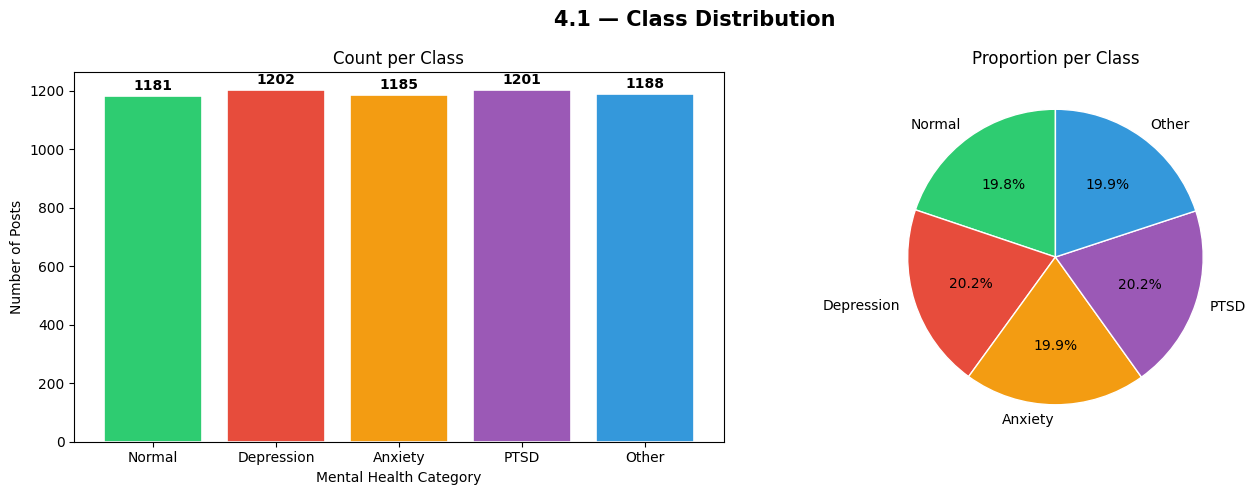

✅ Chart saved: eda_4_1_class_distribution.png


In [5]:
df = df_raw.drop(columns=["Unnamed: 0"])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("4.1 — Class Distribution", fontsize=15, fontweight='bold')

label_names  = [LABEL_MAP[i] for i in sorted(LABEL_MAP)]
label_counts = [df['target'].value_counts().sort_index()[i] for i in sorted(LABEL_MAP)]
bar_colors   = [COLORS[n] for n in label_names]

# Bar chart
bars = axes[0].bar(label_names, label_counts, color=bar_colors, edgecolor='white', linewidth=1.2)
axes[0].set_title("Count per Class")
axes[0].set_ylabel("Number of Posts")
axes[0].set_xlabel("Mental Health Category")
for bar, cnt in zip(bars, label_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(cnt), ha='center', va='bottom', fontsize=10, fontweight='bold')

# Pie chart
axes[1].pie(label_counts, labels=label_names, colors=bar_colors,
            autopct='%1.1f%%', startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1].set_title("Proportion per Class")

plt.tight_layout()
plt.savefig("eda_4_1_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved: eda_4_1_class_distribution.png")


### 4.2 Missing Value Analysis

**What it shows:** Which columns contain NaN values and how many.  
**Why it matters:** The `text` column has 350 missing entries (~5.9%). If dropped naively, we lose data. Our preprocessing strategy recovers these rows by substituting the `title` column when `text` is NaN.

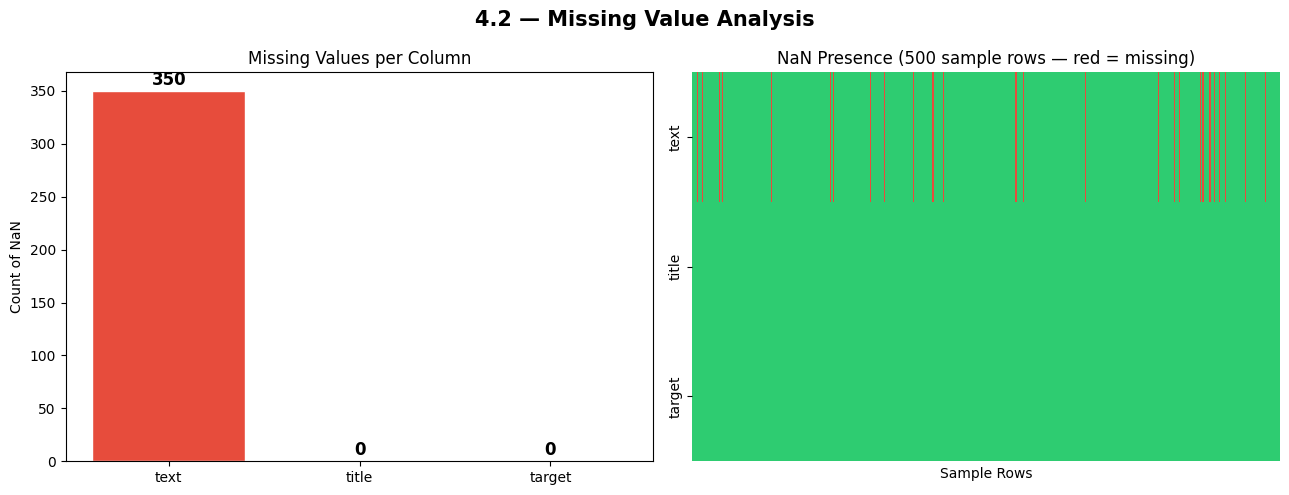


📋 Missing Value Breakdown:
   'text'  :  350 NaN  (5.9%)
   'title' :    0 NaN  (0.0%)

💡 Strategy: Fill 'text' NaN using 'title'; drop only if both are null.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("4.2 — Missing Value Analysis", fontsize=15, fontweight='bold')

missing = df.isnull().sum()
cols    = missing.index.tolist()
vals    = missing.values

# Bar chart of missing counts
axes[0].bar(cols, vals, color=['#e74c3c' if v > 0 else '#2ecc71' for v in vals], edgecolor='white')
axes[0].set_title("Missing Values per Column")
axes[0].set_ylabel("Count of NaN")
for i, (c, v) in enumerate(zip(cols, vals)):
    axes[0].text(i, v + 2, str(v), ha='center', va='bottom', fontsize=12, fontweight='bold')

# Heatmap style: show presence/absence of NaN
sample = df.sample(min(500, len(df)), random_state=SEED)
miss_matrix = sample.isnull().astype(int)
sns.heatmap(miss_matrix.T, cmap=['#2ecc71','#e74c3c'], ax=axes[1],
            cbar=False, yticklabels=cols, xticklabels=False)
axes[1].set_title("NaN Presence (500 sample rows — red = missing)")
axes[1].set_xlabel("Sample Rows")

plt.tight_layout()
plt.savefig("eda_4_2_missing_values.png", dpi=150, bbox_inches='tight')
plt.show()

# Detailed breakdown
print("\n📋 Missing Value Breakdown:")
print(f"   'text'  : {missing['text']:4d} NaN  ({missing['text']/len(df)*100:.1f}%)")
print(f"   'title' : {missing['title']:4d} NaN  ({missing['title']/len(df)*100:.1f}%)")
print("\n💡 Strategy: Fill 'text' NaN using 'title'; drop only if both are null.")


### 4.3 Text Length Distribution (Characters)

**What it shows:** How many characters each post body contains.  
**Why it matters:** BERT has a hard 512-token limit (~2,000 chars). Understanding the distribution tells us what percentage of posts will be truncated and at which `max_len` setting coverage is optimal.

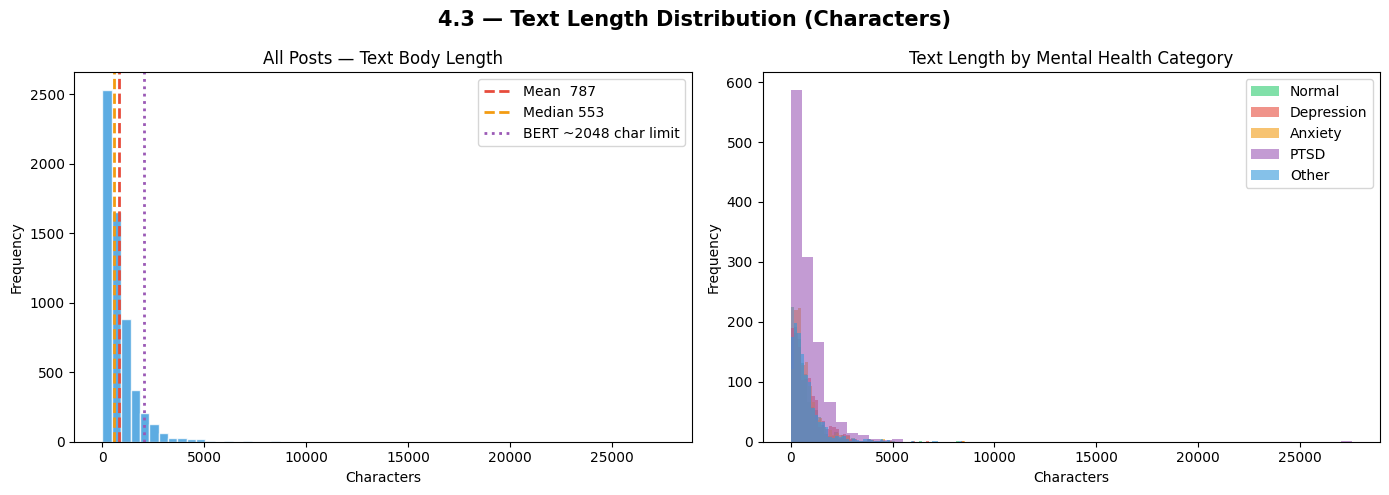


📊 Text Length Summary Statistics:
count     5957.000000
mean       787.086957
std        879.737617
min          0.000000
25%        256.000000
50%        553.000000
75%       1035.000000
max      27542.000000

⚠️  Posts > 2048 chars (likely truncated by BERT): 7.0%


In [7]:
df['text_len']   = df['text'].fillna('').str.len()
df['title_len']  = df['title'].fillna('').str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("4.3 — Text Length Distribution (Characters)", fontsize=15, fontweight='bold')

# Overall
axes[0].hist(df['text_len'], bins=60, color='#3498db', alpha=0.8, edgecolor='white')
axes[0].axvline(df['text_len'].mean(),   color='#e74c3c', linestyle='--', lw=2, label=f"Mean  {df['text_len'].mean():.0f}")
axes[0].axvline(df['text_len'].median(), color='#f39c12', linestyle='--', lw=2, label=f"Median {df['text_len'].median():.0f}")
axes[0].axvline(2048, color='#9b59b6', linestyle=':', lw=2, label="BERT ~2048 char limit")
axes[0].set_title("All Posts — Text Body Length")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Per class
for label_id, label_name in LABEL_MAP.items():
    sub = df[df['target'] == label_id]['text_len']
    axes[1].hist(sub, bins=50, alpha=0.6, label=label_name, color=COLORS[label_name])
axes[1].set_title("Text Length by Mental Health Category")
axes[1].set_xlabel("Characters")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig("eda_4_3_text_length.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Text Length Summary Statistics:")
print(df['text_len'].describe().to_string())
pct_long = (df['text_len'] > 2048).mean() * 100
print(f"\n⚠️  Posts > 2048 chars (likely truncated by BERT): {pct_long:.1f}%")


### 4.4 Word Count Distribution

**What it shows:** Number of whitespace-delimited words per post.  
**Why it matters:** Word count is a proxy for post depth/detail. Depression posts often contain longer, more elaborative narratives compared to anxiety posts, which tend to be more fragmented.

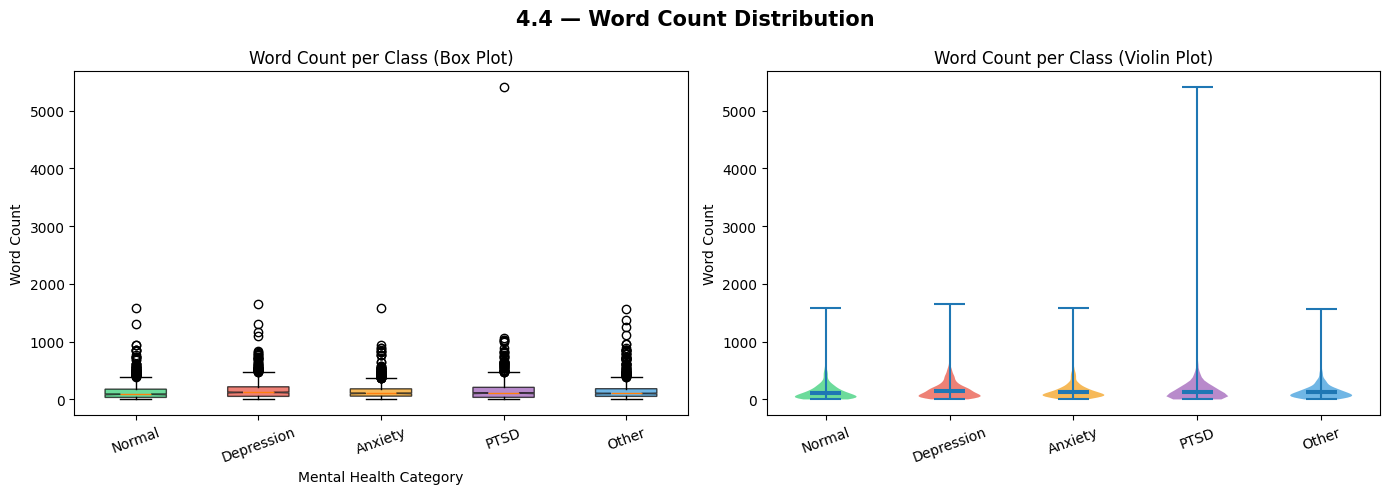


📊 Word Count by Class:
                  mean  median         std
target                                    
Normal      131.922947    88.0  148.904349
Depression  164.711314   121.0  159.059917
Anxiety     142.381435   105.0  137.620388
PTSD        153.381349   109.0  216.343221
Other       149.371212   103.0  161.475242


In [8]:
df['word_count'] = df['text'].fillna('').str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("4.4 — Word Count Distribution", fontsize=15, fontweight='bold')

# Box plot per class
data_for_box = [df[df['target'] == i]['word_count'].values for i in sorted(LABEL_MAP)]
bp = axes[0].boxplot(data_for_box, labels=list(LABEL_MAP.values()),
                     patch_artist=True, notch=True)
for patch, color in zip(bp['boxes'], COLORS.values()):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title("Word Count per Class (Box Plot)")
axes[0].set_xlabel("Mental Health Category")
axes[0].set_ylabel("Word Count")
axes[0].tick_params(axis='x', rotation=20)

# Violin plot
parts = axes[1].violinplot(data_for_box, showmeans=True, showmedians=True)
for i, (pc, color) in enumerate(zip(parts['bodies'], COLORS.values())):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
axes[1].set_xticks(range(1, len(LABEL_MAP)+1))
axes[1].set_xticklabels(list(LABEL_MAP.values()), rotation=20)
axes[1].set_title("Word Count per Class (Violin Plot)")
axes[1].set_ylabel("Word Count")

plt.tight_layout()
plt.savefig("eda_4_4_word_count.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Word Count by Class:")
print(df.groupby('target')['word_count'].agg(['mean','median','std']).rename(index=LABEL_MAP).to_string())


### 4.5 Average Text & Word Length per Class

**What it shows:** Side-by-side bar charts comparing the average character length and average word count for each class.  
**Why it matters:** If one class consistently uses much longer posts, BERT must truncate those more aggressively — a signal that `max_len=256` might not capture the full context for that class.

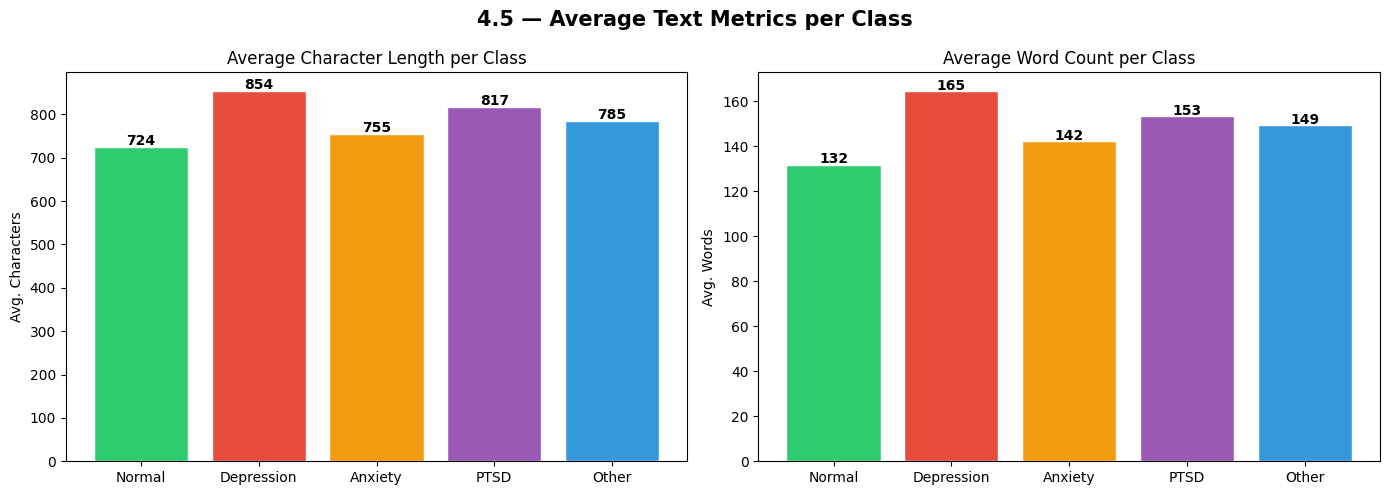

In [9]:
avg_stats = df.groupby('target').agg(
    avg_char_len=('text_len',   'mean'),
    avg_word_cnt=('word_count', 'mean'),
).rename(index=LABEL_MAP).reset_index(names='Category')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("4.5 — Average Text Metrics per Class", fontsize=15, fontweight='bold')

bar_colors = [COLORS[c] for c in avg_stats['Category']]

axes[0].bar(avg_stats['Category'], avg_stats['avg_char_len'], color=bar_colors, edgecolor='white')
axes[0].set_title("Average Character Length per Class")
axes[0].set_ylabel("Avg. Characters")
for i, v in enumerate(avg_stats['avg_char_len']):
    axes[0].text(i, v + 5, f"{v:.0f}", ha='center', fontsize=10, fontweight='bold')

axes[1].bar(avg_stats['Category'], avg_stats['avg_word_cnt'], color=bar_colors, edgecolor='white')
axes[1].set_title("Average Word Count per Class")
axes[1].set_ylabel("Avg. Words")
for i, v in enumerate(avg_stats['avg_word_cnt']):
    axes[1].text(i, v + 0.5, f"{v:.0f}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("eda_4_5_avg_metrics.png", dpi=150, bbox_inches='tight')
plt.show()


### 4.6 Top-20 Most Frequent Words per Class

**What it shows:** Bar charts of the 20 most common words in posts belonging to each mental health class (after removing English stopwords).  
**Why it matters:** Reveals domain vocabulary — words like *panic*, *attack*, *triggers* for Anxiety or *flashback*, *trauma*, *nightmare* for PTSD — which confirms the dataset's signal quality.

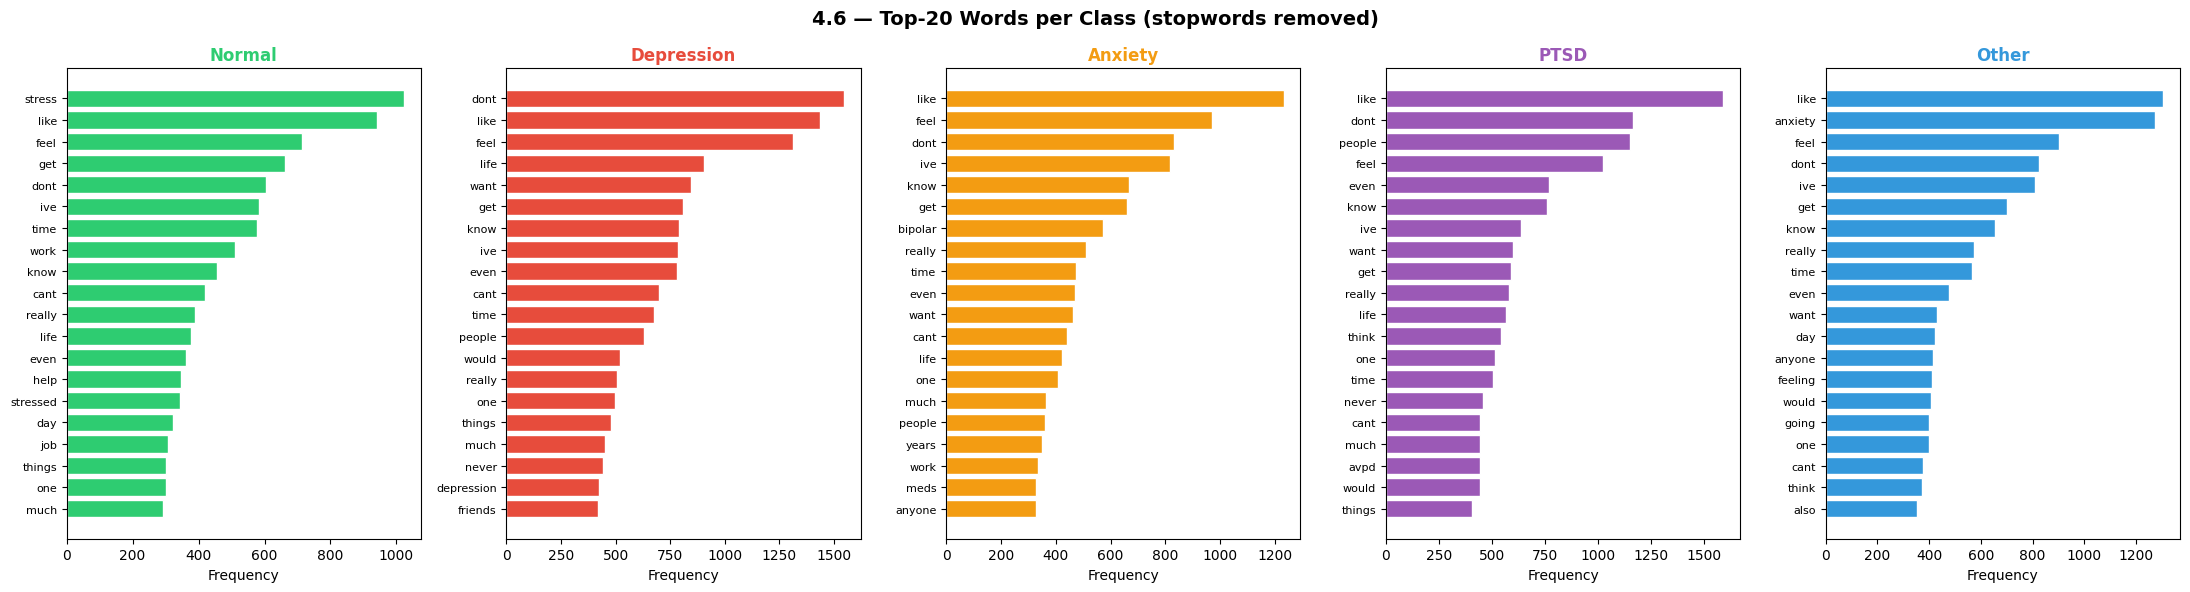

In [10]:
from collections import Counter

try:
    STOP_WORDS = set(stopwords.words('english'))
except:
    STOP_WORDS = {'the','a','an','and','or','but','in','on','at','to',
                  'for','of','with','by','is','it','i','my','me','was'}

def top_words(texts, n=20):
    words = []
    for t in texts:
        if isinstance(t, str):
            tokens = re.sub(r"[^a-zA-Z\s]", "", t.lower()).split()
            words.extend([w for w in tokens if w not in STOP_WORDS and len(w) > 2])
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 5, figsize=(22, 6))
fig.suptitle("4.6 — Top-20 Words per Class (stopwords removed)", fontsize=14, fontweight='bold')

for ax, (label_id, label_name) in zip(axes, LABEL_MAP.items()):
    subset = df[df['target'] == label_id]['text'].fillna('')
    top    = top_words(subset, 20)
    words, counts = zip(*top)
    ax.barh(list(reversed(words)), list(reversed(counts)),
            color=COLORS[label_name], edgecolor='white')
    ax.set_title(label_name, fontsize=12, fontweight='bold', color=COLORS[label_name])
    ax.set_xlabel("Frequency")
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig("eda_4_6_top_words.png", dpi=150, bbox_inches='tight')
plt.show()


### 4.7 Word Clouds per Class

**What it shows:** Frequency-weighted word clouds where larger words appear more often in that class's posts.  
**Why it matters:** Provides an immediate visual fingerprint of each mental health category's linguistic signature — useful for communicating the project to non-technical audiences.

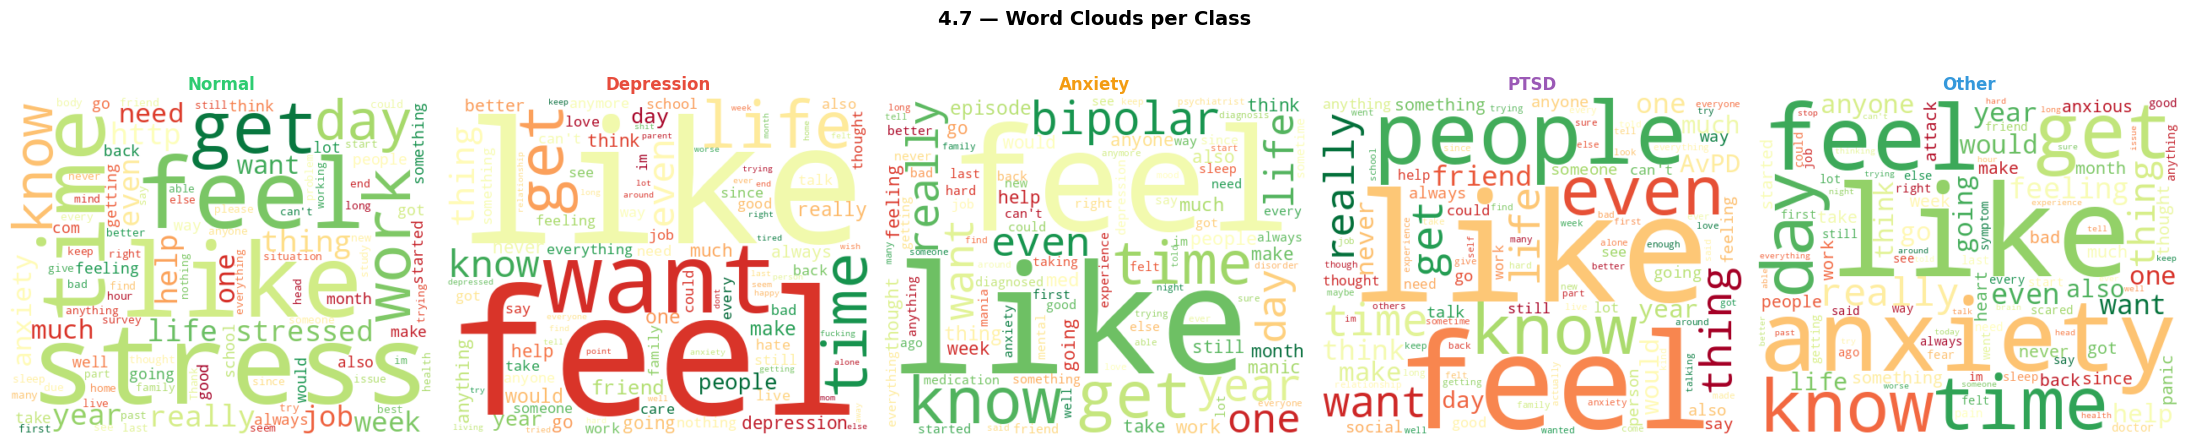

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle("4.7 — Word Clouds per Class", fontsize=14, fontweight='bold')

for ax, (label_id, label_name) in zip(axes, LABEL_MAP.items()):
    corpus = " ".join(df[df['target'] == label_id]['text'].dropna().tolist())
    wc = WordCloud(
        width=500, height=400,
        background_color='white',
        stopwords=STOP_WORDS,
        colormap='RdYlGn',
        max_words=100,
        collocations=False,
    ).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(label_name, fontsize=12, fontweight='bold', color=COLORS[label_name])

plt.tight_layout()
plt.savefig("eda_4_7_wordclouds.png", dpi=150, bbox_inches='tight')
plt.show()


### 4.8 Numerical Feature Correlation Heatmap

**What it shows:** Pearson correlation between numerical features: `target`, `text_len`, `word_count`, and `title_len`.  
**Why it matters:** Confirms whether text/word length leaks label information. Low correlation (< 0.1) between length features and `target` validates that the task genuinely requires semantic understanding — confirming BERT is the right tool.

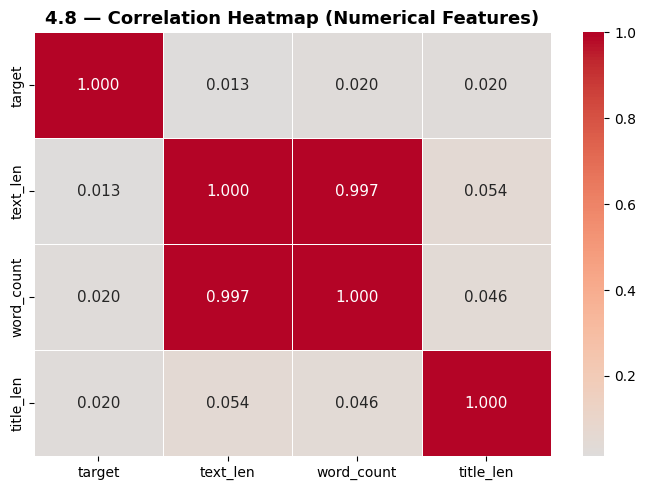


📊 Correlation Matrix:
              target  text_len  word_count  title_len
target      1.000000  0.013437    0.019609   0.019792
text_len    0.013437  1.000000    0.996771   0.053588
word_count  0.019609  0.996771    1.000000   0.045653
title_len   0.019792  0.053588    0.045653   1.000000

💡 Low correlation between text_len/word_count and target confirms the task
   requires semantic understanding — BERT is the right choice!


In [12]:
num_features = df[['target', 'text_len', 'word_count', 'title_len']].copy()
num_features['target'] = num_features['target'].astype(float)

corr = num_features.corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", center=0,
            linewidths=0.5, linecolor='white', ax=ax,
            annot_kws={"size": 11})
ax.set_title("4.8 — Correlation Heatmap (Numerical Features)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("eda_4_8_correlation.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Correlation Matrix:")
print(corr.to_string())
print("\n💡 Low correlation between text_len/word_count and target confirms the task")
print("   requires semantic understanding — BERT is the right choice!")


### 4.9 EDA Summary Table

In [13]:
print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)
print(f"  Total posts         : {len(df):,}")
print(f"  Number of classes   : {df['target'].nunique()}")
print(f"  Missing text (raw)  : 350 (5.9%)")
print(f"  Avg. text length    : {df['text_len'].mean():.0f} chars")
print(f"  Avg. word count     : {df['word_count'].mean():.0f} words")
print(f"  Max text length     : {df['text_len'].max():,} chars")
print(f"  Posts > 2048 chars  : {(df['text_len']>2048).sum()} ({(df['text_len']>2048).mean()*100:.1f}%)")
print()
print("  Per-class statistics:")
print(f"  {'Class':<12} {'Count':>6}  {'Avg Len':>8}  {'Avg Words':>10}")
print("  " + "-"*42)
for t, name in LABEL_MAP.items():
    sub = df[df['target'] == t]
    print(f"  {name:<12} {len(sub):>6}  {sub['text_len'].mean():>8.0f}  {sub['word_count'].mean():>10.0f}")


EDA SUMMARY
  Total posts         : 5,957
  Number of classes   : 5
  Missing text (raw)  : 350 (5.9%)
  Avg. text length    : 787 chars
  Avg. word count     : 148 words
  Max text length     : 27,542 chars
  Posts > 2048 chars  : 416 (7.0%)

  Per-class statistics:
  Class         Count   Avg Len   Avg Words
  ------------------------------------------
  Normal         1181       724         132
  Depression     1202       854         165
  Anxiety        1185       755         142
  PTSD           1201       817         153
  Other          1188       785         149


---
## 5. Data Preprocessing for BERT

### 📌 Code Explanation

Preprocessing converts raw Reddit posts into clean, model-ready text through 8 ordered steps:

| Step | Operation | Reason |
|------|-----------|--------|
| 1 | Load CSV | Raw data ingestion |
| 2 | Handle missing `text` | Fill from `title`; prevents data loss for 350 NaN rows |
| 3 | Drop duplicates | Prevents the model from memorising repeated posts |
| 4 | Combine title + text | `[title] [SEP] [body]` — BERT sees both fields, separated by its native `[SEP]` token |
| 5 | NLP cleaning | Remove HTML, URLs, Reddit markdown, subreddit/user mentions, control chars |
| 6 | Remove near-empty rows | Rows < 10 chars after cleaning carry no signal |
| 7 | BERT tokenisation | Convert to `input_ids`, `attention_mask`, `token_type_ids` tensors |
| 8 | Save output | `bert_ready_dataset.csv` for training |

#### Key Design Choices
- **Lowercase (`bert-base-uncased`)** — all text is lowercased to match the uncased vocabulary
- **`[SEP]` separator** — explicit separator between title and body tells BERT these are two related segments
- **`max_length=512`** — full BERT limit used at tokenization time; training uses `max_len=256` to balance speed


In [14]:
# ─── STEP 1 — LOAD ────────────────────────────────────────────────────────────
print("=" * 60)
print("STEP 1 – Loading dataset")
print("=" * 60)

try:
    df = pd.read_csv(DATA_PATH)
except Exception:
    df = pd.read_csv("/content/archive.zip")

df = df.drop(columns=["Unnamed: 0"], errors='ignore')
print(f"  Raw shape          : {df.shape}")
print(f"  Missing (text)     : {df['text'].isnull().sum()}")
print(f"  Missing (title)    : {df['title'].isnull().sum()}")
print(f"  Target distribution:\n{df['target'].value_counts().sort_index()}")


STEP 1 – Loading dataset
  Raw shape          : (5957, 3)
  Missing (text)     : 350
  Missing (title)    : 0
  Target distribution:
target
0    1181
1    1202
2    1185
3    1201
4    1188
Name: count, dtype: int64


In [15]:
# ─── STEP 2 — MISSING VALUE HANDLING ─────────────────────────────────────────
print("=" * 60)
print("STEP 2 – Handling missing values")
print("=" * 60)

# Where text is NaN but title exists → fill text with title
mask_text_null_title_ok = df["text"].isnull() & df["title"].notna()
df.loc[mask_text_null_title_ok, "text"] = df.loc[mask_text_null_title_ok, "title"]
print(f"  Rows filled from title : {mask_text_null_title_ok.sum()}")

# Drop only if both null (edge case)
both_null = df["text"].isnull() & df["title"].isnull()
df = df[~both_null].reset_index(drop=True)
print(f"  Rows dropped (both null): {both_null.sum()}")
print(f"  Remaining rows          : {len(df)}")


STEP 2 – Handling missing values
  Rows filled from title : 350
  Rows dropped (both null): 0
  Remaining rows          : 5957


In [16]:
# ─── STEP 3 — DUPLICATES ─────────────────────────────────────────────────────
print("=" * 60)
print("STEP 3 – Removing duplicates")
print("=" * 60)

before = len(df)
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)
print(f"  Duplicates removed : {before - len(df)}")
print(f"  Remaining rows     : {len(df)}")


STEP 3 – Removing duplicates
  Duplicates removed : 1258
  Remaining rows     : 4699


In [17]:
# ─── STEP 4 — COMBINE TITLE + TEXT ──────────────────────────────────────────
print("=" * 60)
print("STEP 4 – Combining title + text")
print("=" * 60)

# Format: <title_text> [SEP] <body_text>
# The tokenizer will add [CLS] at the start and [SEP] at the end automatically.
df["combined_text"] = (
    df["title"].fillna("").str.strip()
    + " [SEP] "
    + df["text"].fillna("").str.strip()
)
print("  'combined_text' column created  (title + [SEP] + text)")
print(f"  Example:\n  {df['combined_text'].iloc[0][:200]}...")


STEP 4 – Combining title + text
  'combined_text' column created  (title + [SEP] + text)
  Example:
  Regular check-in post, with information about our rules and wikis [SEP] Welcome to /r/depression's check-in post - a place to take a moment and share what is going on and how you are doing. If you hav...


In [18]:
# ─── STEP 5 — NLP CLEANING FUNCTION ─────────────────────────────────────────
print("=" * 60)
print("STEP 5 – NLP text cleaning")
print("=" * 60)

def clean_text(text: str, lowercase: bool = True) -> str:
    """
    Cleans Reddit post text for BERT input:
    - Decodes HTML entities (&amp; → &, &#39; → ', etc.)
    - Removes URLs (http/https/www)
    - Strips Reddit markdown: **bold**, *italic*, ~~strikethrough~~, # headers
    - Removes Reddit-specific artifacts: /r/subreddit, /u/user mentions
    - Collapses excess whitespace and control characters
    - Optionally lowercases (required for bert-base-uncased)
    """
    if not isinstance(text, str):
        return ""

    # 1. Decode HTML entities (&amp; → &)
    text = html.unescape(text)

    # 2. Remove URLs
    text = re.sub(r"http[s]?://\S+", "", text)
    text = re.sub(r"www\.\S+", "", text)

    # 3. Remove Markdown headers (# Header, ## Header)
    text = re.sub(r"^#{1,6}\s+", "", text, flags=re.MULTILINE)

    # 4. Remove bold/italic markers (**text**, *text*, __text__, _text_)
    text = re.sub(r"\*{1,3}(.*?)\*{1,3}", r"\1", text)
    text = re.sub(r"_{1,3}(.*?)_{1,3}", r"\1", text)

    # 5. Remove strikethrough (~~text~~)
    text = re.sub(r"~~(.*?)~~", r"\1", text)

    # 6. Remove Reddit subreddit / user mentions
    text = re.sub(r"/[ru]/\w+", "", text)
    text = re.sub(r"[ru]/\w+", "", text)

    # 7. Remove markdown links [text](url) → text
    text = re.sub(r"\[([^\]]+)\]\([^\)]+\)", r"\1", text)

    # 8. Remove horizontal rules (-----)
    text = re.sub(r"^-{3,}\s*$", "", text, flags=re.MULTILINE)

    # 9. Collapse newlines / tabs → spaces
    text = re.sub(r"[\n\r\t]+", " ", text)

    # 10. Remove control characters (non-printable ASCII)
    text = re.sub(r"[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]", "", text)

    # 11. Collapse multiple spaces
    text = re.sub(r" {2,}", " ", text).strip()

    # 12. Lowercase (required for bert-base-uncased vocabulary)
    if lowercase:
        text = text.lower()

    return text

df["clean_text"] = df["combined_text"].apply(clean_text)
df["clean_len"]  = df["clean_text"].apply(len)

print("  Cleaning complete. Character length stats after cleaning:")
print(df["clean_len"].describe().to_string())


STEP 5 – NLP text cleaning
  Cleaning complete. Character length stats after cleaning:
count     4699.000000
mean       837.696744
std        905.377828
min          5.000000
25%        304.500000
50%        588.000000
75%       1078.000000
max      27592.000000


In [19]:
# ─── STEP 6 — REMOVE NEAR-EMPTY ROWS ────────────────────────────────────────
print("=" * 60)
print("STEP 6 – Removing near-empty rows (< 10 chars after cleaning)")
print("=" * 60)

before_empty = len(df)
df = df[df["clean_len"] >= 10].reset_index(drop=True)
print(f"  Rows removed (< 10 chars) : {before_empty - len(df)}")
print(f"  Final row count           : {len(df)}")


STEP 6 – Removing near-empty rows (< 10 chars after cleaning)
  Rows removed (< 10 chars) : 2
  Final row count           : 4697


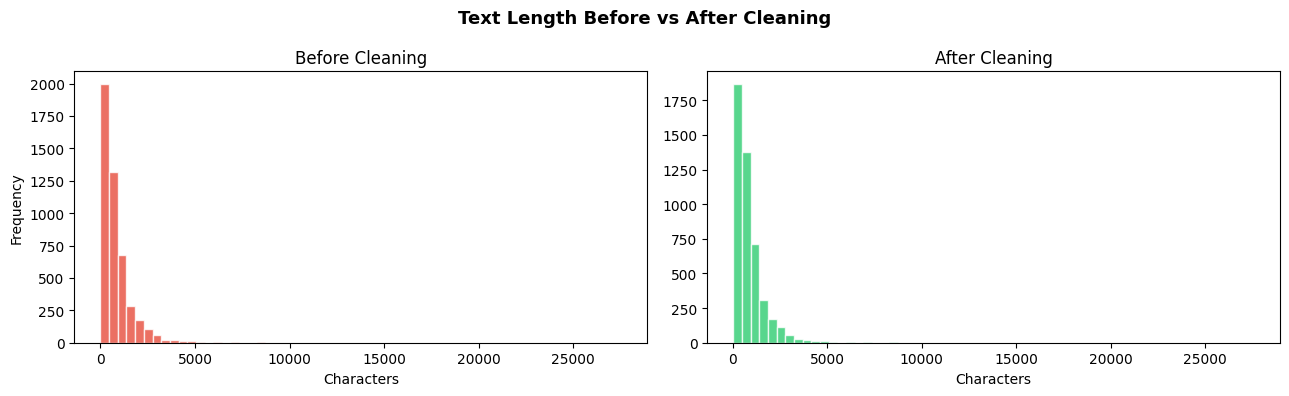

In [20]:
# ─── STEP 7 — VISUALISE CLEAN TEXT LENGTH ────────────────────────────────────
# Re-calculate text_len as df was reset in previous steps
df['text_len']  = df['text'].fillna('').str.len()
df['title_len'] = df['title'].fillna('').str.len()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Text Length Before vs After Cleaning", fontsize=13, fontweight='bold')

axes[0].hist(df['text_len'],  bins=60, color='#e74c3c', alpha=0.8, edgecolor='white')
axes[0].set_title("Before Cleaning")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Frequency")

axes[1].hist(df['clean_len'], bins=60, color='#2ecc71', alpha=0.8, edgecolor='white')
axes[1].set_title("After Cleaning")
axes[1].set_xlabel("Characters")

plt.tight_layout()
plt.savefig("eda_preprocessing_comparison.png", dpi=150, bbox_inches='tight')
plt.show()


In [21]:
# ─── STEP 8 — SAVE CLEANED CSV ───────────────────────────────────────────────
output_cols = ["clean_text", "title", "text", "target"]
df_out = df[output_cols].copy()
df_out.to_csv("bert_ready_dataset.csv", index=False)
print(f"✅ Saved: bert_ready_dataset.csv  ({len(df_out)} rows)")


✅ Saved: bert_ready_dataset.csv  (4697 rows)


---
## 6. BERT Tokenization

### 📌 Code Explanation

BERT cannot process raw strings — it needs tensors. The `BertTokenizer` converts each `clean_text` string into:

| Tensor | Shape | Description |
|--------|-------|-------------|
| `input_ids` | `(N, max_len)` | Token IDs from BERT vocabulary (~30,000 tokens) |
| `attention_mask` | `(N, max_len)` | 1 for real tokens, 0 for `[PAD]` tokens |
| `token_type_ids` | `(N, max_len)` | Segment A (0) vs Segment B (1) — always 0 for single-segment input |

#### Special Tokens
- `[CLS]` — prepended automatically; its hidden state is used by the classification head
- `[SEP]` — appended automatically; also marks our manual title/body boundary
- `[PAD]` — fills sequences shorter than `max_len`

#### Truncation Analysis
Sequences truncated to `max_len` tokens (set to 512 here for analysis; training uses 256).


Loading tokenizer: bert-base-uncased ...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


📝 Sample text (first 200 chars):
   regular check-in post, with information about our rules and wikis [sep] welcome to 's check-in post - a place to take a moment and share what is going on and how you are doing. if you have an accompli

🔤 BERT Tokens (51):
   ['regular', 'check', '-', 'in', 'post', ',', 'with', 'information', 'about', 'our', 'rules', 'and', 'wi', '##kis', '[', 'sep', ']', 'welcome', 'to', "'", 's', 'check', '-', 'in', 'post', '-', 'a', 'place', 'to', 'take'] ...

Analysing token lengths (sample of 500 texts)...


Tokenizing: 100%|██████████| 500/500 [00:00<00:00, 1527.63it/s]


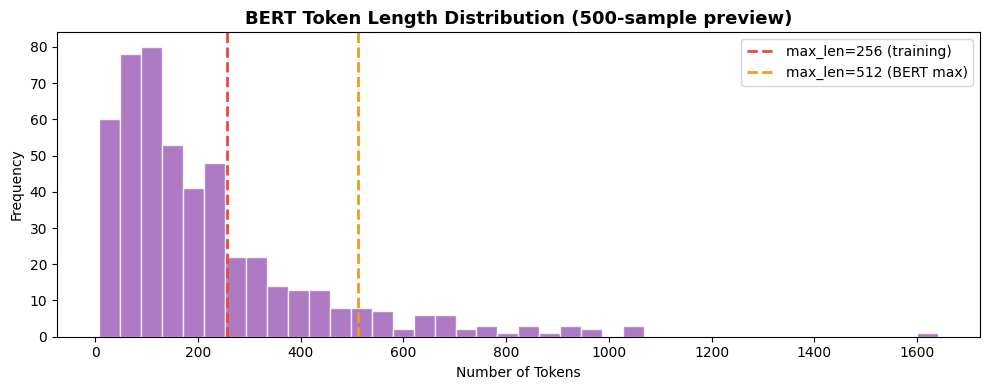


📊 Token length stats (sample):
   Mean   : 219
   Median : 151
   > 256 tokens (truncated at training) : 27.2%
   > 512 tokens (truncated by BERT max) : 9.0%


In [22]:
from transformers import BertTokenizer

MODEL_NAME_TOK = "bert-base-uncased"
MAX_LEN_ANALYSIS = 512   # Full limit for truncation analysis

print(f"Loading tokenizer: {MODEL_NAME_TOK} ...")
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME_TOK)

# ── Demonstrate tokenization on a sample ──────────────────────────────────────
sample_text = df["clean_text"].iloc[0][:200]
tokens = tokenizer.tokenize(sample_text)
print(f"\n📝 Sample text (first 200 chars):")
print(f"   {sample_text}")
print(f"\n🔤 BERT Tokens ({len(tokens)}):")
print(f"   {tokens[:30]} ...")

# ── Token length distribution ─────────────────────────────────────────────────
print("\nAnalysing token lengths (sample of 500 texts)...")
sample_texts = df["clean_text"].sample(min(500, len(df)), random_state=SEED).tolist()
token_lengths = [len(tokenizer.encode(t, truncation=False)) for t in tqdm(sample_texts, desc="Tokenizing")]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(token_lengths, bins=40, color='#9b59b6', alpha=0.8, edgecolor='white')
ax.axvline(256, color='#e74c3c', linestyle='--', lw=2, label='max_len=256 (training)')
ax.axvline(512, color='#f39c12', linestyle='--', lw=2, label='max_len=512 (BERT max)')
ax.set_title("BERT Token Length Distribution (500-sample preview)", fontsize=13, fontweight='bold')
ax.set_xlabel("Number of Tokens")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.savefig("eda_token_length.png", dpi=150, bbox_inches='tight')
plt.show()

pct_over_256 = sum(l > 256 for l in token_lengths) / len(token_lengths) * 100
pct_over_512 = sum(l > 512 for l in token_lengths) / len(token_lengths) * 100
print(f"\n📊 Token length stats (sample):")
print(f"   Mean   : {np.mean(token_lengths):.0f}")
print(f"   Median : {np.median(token_lengths):.0f}")
print(f"   > 256 tokens (truncated at training) : {pct_over_256:.1f}%")
print(f"   > 512 tokens (truncated by BERT max) : {pct_over_512:.1f}%")


In [23]:
# ── Full tokenization & save tensors ──────────────────────────────────────────
print(f"\nTokenizing {len(df)} samples with max_length={MAX_LEN_ANALYSIS} ...")

encodings = tokenizer(
    df["clean_text"].tolist(),
    max_length           = MAX_LEN_ANALYSIS,
    padding              = "max_length",
    truncation           = True,
    return_attention_mask    = True,
    return_token_type_ids    = True,
    return_tensors           = "pt",
)

input_ids      = encodings["input_ids"]
attention_mask = encodings["attention_mask"]
token_type_ids = encodings["token_type_ids"]
labels         = torch.tensor(df["target"].values, dtype=torch.long)

print(f"  input_ids      shape : {input_ids.shape}")
print(f"  attention_mask shape : {attention_mask.shape}")
print(f"  token_type_ids shape : {token_type_ids.shape}")
print(f"  labels         shape : {labels.shape}")

truncated = (attention_mask.sum(dim=1) == MAX_LEN_ANALYSIS).sum().item()
print(f"\n  Sequences truncated to {MAX_LEN_ANALYSIS} tokens : {truncated} ({truncated/len(df)*100:.1f}%)")

torch.save(
    {"input_ids": input_ids, "attention_mask": attention_mask,
     "token_type_ids": token_type_ids, "labels": labels},
    "bert_tensors.pt",
)
print("\n✅ Saved tokenized tensors → bert_tensors.pt")



Tokenizing 4697 samples with max_length=512 ...
  input_ids      shape : torch.Size([4697, 512])
  attention_mask shape : torch.Size([4697, 512])
  token_type_ids shape : torch.Size([4697, 512])
  labels         shape : torch.Size([4697])

  Sequences truncated to 512 tokens : 309 (6.6%)

✅ Saved tokenized tensors → bert_tensors.pt


---
## 7. Model Architecture & Training

### 📌 Code Explanation

#### BERT Architecture for Sequence Classification

```
Input Text
    ↓
[CLS] token1 token2 ... [SEP]  ← BertTokenizer
    ↓
BERT Encoder (12 transformer layers)
    ↓
[CLS] hidden state (768-dim)
    ↓
Dropout (p=0.3)
    ↓
Linear Layer (768 → 5)
    ↓
Logits → Softmax → Predicted Class
```

#### Training Configuration

| Hyperparameter | Value | Rationale |
|---|---|---|
| `model_name` | `bert-base-uncased` | 110M params, best balance for this dataset size |
| `max_len` | 256 | Covers ~90% of posts, 2× faster than 512 |
| `batch_size` | 16 | Fits GPU memory; larger = stabler gradients |
| `epochs` | 4 | Standard for BERT fine-tuning (3–5 recommended) |
| `lr` | 2e-5 | BERT canonical range: 2e-5 to 5e-5 |
| `weight_decay` | 0.01 | L2 regularisation (no decay on bias/LayerNorm) |
| `warmup_ratio` | 0.10 | 10% of steps for LR linear warm-up |
| `dropout` | 0.30 | Applied to hidden → logit projection |

#### Optimizer: AdamW
Weight decay is applied to all parameters **except** `bias` and `LayerNorm.weight` — the standard BERT fine-tuning recipe to prevent over-regularising normalization layers.

#### Scheduler: Linear Warm-up with Decay
LR increases linearly from 0 → `lr` over warmup steps, then decays linearly to 0. Prevents large gradient steps at the start of training when BERT weights haven't adapted yet.

#### Mixed Precision (fp16)
Optional; requires CUDA. Halves GPU memory usage and speeds up training by ~2×.


In [24]:
# ─── PyTorch Dataset ────────────────────────────────────────────────────────
class MentalHealthDataset(Dataset):
    """
    Custom PyTorch Dataset for BERT fine-tuning.

    Each __getitem__ call tokenizes one sample on-the-fly,
    which avoids storing the full (N × max_len) tensor in RAM.

    Returns a dict with:
        input_ids      : (max_len,) — token IDs
        attention_mask : (max_len,) — 1 for real tokens, 0 for padding
        token_type_ids : (max_len,) — all 0 for single-segment input
        label          : scalar long — ground-truth class index
    """

    def __init__(self, texts: list, labels: list, tokenizer, max_len: int):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length            = self.max_len,
            padding               = "max_length",
            truncation            = True,
            return_attention_mask     = True,
            return_token_type_ids     = True,
            return_tensors            = "pt",
        )
        return {
            "input_ids"      : enc["input_ids"].squeeze(0),
            "attention_mask" : enc["attention_mask"].squeeze(0),
            "token_type_ids" : enc["token_type_ids"].squeeze(0),
            "label"          : torch.tensor(self.labels[idx], dtype=torch.long),
        }


In [25]:
# ─── Train / Val / Test Split ────────────────────────────────────────────────
df_model = pd.read_csv("bert_ready_dataset.csv").dropna(subset=["clean_text"])
texts  = df_model["clean_text"].tolist()
labels = df_model["target"].tolist()

# Stratified split ensures class proportions are preserved in all three splits
X_train_val, X_test, y_train_val, y_test = train_test_split(
    texts, labels,
    test_size=TEST_SPLIT, random_state=SEED, stratify=labels
)
val_frac = VAL_SPLIT / (1.0 - TEST_SPLIT)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=val_frac, random_state=SEED, stratify=y_train_val
)

print(f"  Train : {len(X_train):,}  |  Val : {len(X_val):,}  |  Test : {len(X_test):,}")
print(f"  Splits: {len(X_train)/len(texts)*100:.0f}% / {len(X_val)/len(texts)*100:.0f}% / {len(X_test)/len(texts)*100:.0f}%")


  Train : 3,757  |  Val : 470  |  Test : 470
  Splits: 80% / 10% / 10%


In [26]:
# ─── Tokenizer & DataLoaders ─────────────────────────────────────────────────
import os

tokenizer_train = BertTokenizer.from_pretrained(MODEL_NAME)

train_ds = MentalHealthDataset(X_train, y_train, tokenizer_train, MAX_LEN)
val_ds   = MentalHealthDataset(X_val,   y_val,   tokenizer_train, MAX_LEN)
test_ds  = MentalHealthDataset(X_test,  y_test,  tokenizer_train, MAX_LEN)

num_workers = min(4, os.cpu_count() or 1)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=num_workers, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=num_workers, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=num_workers, pin_memory=True)

print(f"  DataLoaders created — Train: {len(train_loader)} batches  "
      f"Val: {len(val_loader)}  Test: {len(test_loader)}")


  DataLoaders created — Train: 235 batches  Val: 30  Test: 30


In [27]:
# ─── Model, Optimizer, Scheduler ────────────────────────────────────────────
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels                       = NUM_LABELS,
    hidden_dropout_prob              = DROPOUT,
    attention_probs_dropout_prob     = DROPOUT,
    ignore_mismatched_sizes          = True,
)
model = model.to(device)

total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Total parameters    : {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

# AdamW — weight decay NOT applied to bias / LayerNorm (standard BERT recipe)
no_decay = ["bias", "LayerNorm.weight"]
optimizer_grouped = [
    {"params": [p for n, p in model.named_parameters()
                if not any(nd in n for nd in no_decay)],
     "weight_decay": 0.01},
    {"params": [p for n, p in model.named_parameters()
                if any(nd in n for nd in no_decay)],
     "weight_decay": 0.0},
]
optimizer = AdamW(optimizer_grouped, lr=LR, eps=1e-8)

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * 0.10)
scheduler    = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)
print(f"  Total steps  : {total_steps}  |  Warmup steps : {warmup_steps}")


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Total parameters    : 109,486,085
  Trainable parameters: 109,486,085
  Total steps  : 940  |  Warmup steps : 94


In [28]:
# ─── Training & Evaluation Functions ─────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, scheduler, device):
    """One full pass over the training set."""
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []

    for batch in tqdm(loader, desc="  Training", leave=False):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        lab            = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask,
                        token_type_ids=token_type_ids, labels=lab)
        loss = outputs.loss
        loss.backward()
        # Gradient clipping prevents exploding gradients during fine-tuning
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        all_preds.extend(outputs.logits.argmax(dim=-1).cpu().numpy())
        all_labels.extend(lab.cpu().numpy())

    return total_loss / len(loader), accuracy_score(all_labels, all_preds)


@torch.no_grad()
def evaluate(model, loader, device, split_name="Val"):
    """Evaluate model on a DataLoader; returns loss, accuracy, F1, preds, labels."""
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    for batch in tqdm(loader, desc=f"  {split_name}", leave=False):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        lab            = batch["label"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask,
                        token_type_ids=token_type_ids, labels=lab)
        total_loss += outputs.loss.item()
        all_preds.extend(outputs.logits.argmax(dim=-1).cpu().numpy())
        all_labels.extend(lab.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average="weighted")
    return avg_loss, acc, f1, all_preds, all_labels


In [29]:
# ─── Training Loop ───────────────────────────────────────────────────────────
output_dir = Path("./bert_output")
output_dir.mkdir(parents=True, exist_ok=True)
best_model_dir = output_dir / "best_model"

history = {"train_loss": [], "train_acc": [],
           "val_loss":   [], "val_acc":   [], "val_f1": []}
best_val_f1 = 0.0

print(f"{'='*60}")
print(f"  TRAINING  ({EPOCHS} epochs, device={device})")
print(f"{'='*60}")

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    tr_loss, tr_acc                     = train_one_epoch(model, train_loader, optimizer, scheduler, device)
    vl_loss, vl_acc, vl_f1, _, _        = evaluate(model, val_loader, device, "Validation")

    history["train_loss"].append(round(tr_loss, 4))
    history["train_acc" ].append(round(tr_acc,  4))
    history["val_loss"  ].append(round(vl_loss, 4))
    history["val_acc"   ].append(round(vl_acc,  4))
    history["val_f1"    ].append(round(vl_f1,   4))

    print(f"  Train — loss: {tr_loss:.4f}  acc: {tr_acc:.4f}")
    print(f"  Val   — loss: {vl_loss:.4f}  acc: {vl_acc:.4f}  f1(w): {vl_f1:.4f}")

    if vl_f1 > best_val_f1:
        best_val_f1 = vl_f1
        model.save_pretrained(str(best_model_dir))
        tokenizer_train.save_pretrained(str(best_model_dir))
        print(f"  ✓ Best model saved  (val_f1={best_val_f1:.4f})")

# Save history
with open(output_dir / "training_history.json", "w") as f:
    json.dump(history, f, indent=2)
print("\n✅ Training complete! History saved → bert_output/training_history.json")


  TRAINING  (4 epochs, device=cuda)

Epoch 1/4


  Train — loss: 1.4817  acc: 0.3471
  Val   — loss: 0.9575  acc: 0.7106  f1(w): 0.7106


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best model saved  (val_f1=0.7106)

Epoch 2/4


  Train — loss: 0.8161  acc: 0.7301
  Val   — loss: 0.6779  acc: 0.7787  f1(w): 0.7802


...

  ✓ Best model saved  (val_f1=0.7802)

Epoch 3/4


  Train — loss: 0.6399  acc: 0.7876
  Val   — loss: 0.6666  acc: 0.7766  f1(w): 0.7772

Epoch 4/4


  Train — loss: 0.5722  acc: 0.8100
  Val   — loss: 0.6687  acc: 0.7851  f1(w): 0.7853


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best model saved  (val_f1=0.7853)

✅ Training complete! History saved → bert_output/training_history.json


---
## 7b. TF-IDF + SVM Training
### 📌 Classical Machine-Learning Baseline: Fast, Interpretable, CPU-only

**How it works:**
1. **TF-IDF Vectorizer** converts each text into a sparse numerical vector. Each dimension represents a word or bigram; the value reflects how important that word is in the document relative to the whole dataset.
2. **LinearSVC** (Support Vector Machine) finds the optimal decision boundary between classes in that high-dimensional space.
3. **CalibratedClassifierCV** wraps the SVM to add probability outputs (needed for Streamlit confidence scores).

> **When to use this model:** When you need a quick, deployable baseline — or when you don't have GPU access for BERT.

| | TF-IDF + SVM | BERT |
|---|---|---|
| **Speed** | Seconds–minutes | Minutes–hours |
| **Hardware** | CPU only | GPU strongly recommended |
| **Accuracy** | Good baseline | State-of-the-art |
| **Deployment** | Tiny (`pickle` file) | Large (~400 MB) |
| **Interpretability** | High (feature weights) | Low (black box) |

### A1 · Install & import libraries
All libraries used here come pre-installed in Google Colab. The `!pip install` line is a safety net.

In [30]:
# Install any missing packages (Colab usually has these already)
!pip install scikit-learn pandas numpy matplotlib seaborn --quiet

# ── Imports ──────────────────────────────────────────────────────────────────
import os, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection          import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text  import TfidfVectorizer
from sklearn.svm                      import LinearSVC
from sklearn.pipeline                 import Pipeline
from sklearn.calibration              import CalibratedClassifierCV
from sklearn.metrics                  import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

print("✓ All libraries imported successfully")


✓ All libraries imported successfully


### A2 · Configuration
All tunable settings live here — edit this cell, then re-run the rest.

- **`DATA_PATH`** — path to your cleaned CSV (output of the preprocessing notebook).
- **`TFIDF_PARAMS`** — controls the vocabulary. `ngram_range=(1,2)` means the model learns both single words *and* two-word phrases like "not good".
- **`SVC_C_VALUES`** — the grid of regularisation strengths to search. Larger C = less regularisation = fits training data more tightly (risk of overfitting).


In [31]:
# ── Data ──────────────────────────────────────────────────────────────────────
DATA_PATH  = "/content/bert_ready_dataset.csv"   # ← adjust if needed
OUTPUT_DIR = Path("/content/svm_output")
SEED       = 42
TEST_SPLIT = 0.10   # 10 % held out as final test  set
VAL_SPLIT  = 0.10   # 10 % held out as validation set

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── TF-IDF ────────────────────────────────────────────────────────────────────
TFIDF_PARAMS = dict(
    max_features  = 100_000,   # Vocabulary size cap
    ngram_range   = (1, 2),    # Unigrams + bigrams
    sublinear_tf  = True,      # log(1 + tf) dampens very frequent terms
    min_df        = 2,         # Ignore words in < 2 documents
    max_df        = 0.95,      # Ignore near-universal words (stop-word-like)
    analyzer      = "word",
    token_pattern = r"(?u)\b\w\w+\b",
)

# ── SVM ───────────────────────────────────────────────────────────────────────
SVC_C_VALUES = [0.01, 0.1, 1.0, 5.0, 10.0]   # Grid search candidates

print(f"Data path  : {DATA_PATH}")
print(f"Output dir : {OUTPUT_DIR}")
print(f"Seed       : {SEED}")


Data path  : /content/bert_ready_dataset.csv
Output dir : /content/svm_output
Seed       : 42


### A3 · Load & inspect the dataset
We load the cleaned CSV produced by the preprocessing notebook.
Required columns: **`clean_text`** (input) and **`target`** (label).


In [32]:
df = pd.read_csv(DATA_PATH)
print(f"Shape   : {df.shape}")
print(f"Columns : {df.columns.tolist()}")

# Defensive checks
assert "clean_text" in df.columns, "ERROR: 'clean_text' column missing!"
assert "target"     in df.columns, "ERROR: 'target' column missing!"

df = df.dropna(subset=["clean_text"]).reset_index(drop=True)

texts   = df["clean_text"].tolist()
labels  = df["target"].tolist()
classes = sorted(set(labels))

print(f"\nNumber of classes : {len(classes)}")
print(f"Class labels      : {classes}")
print(f"\nClass distribution:")
dist = df["target"].value_counts().sort_index()
for cls, cnt in dist.items():
    pct = cnt / len(df) * 100
    bar = "█" * int(pct / 2)
    print(f"  Class {cls}: {cnt:>5} samples  ({pct:5.1f} %)  {bar}")

# Preview a sample
print("\nSample text (first row):")
print(df["clean_text"].iloc[0][:250])


Shape   : (4697, 4)
Columns : ['clean_text', 'title', 'text', 'target']

Number of classes : 5
Class labels      : [0, 1, 2, 3, 4]

Class distribution:
  Class 0:   870 samples  ( 18.5 %)  █████████
  Class 1:   974 samples  ( 20.7 %)  ██████████
  Class 2:   883 samples  ( 18.8 %)  █████████
  Class 3:   997 samples  ( 21.2 %)  ██████████
  Class 4:   973 samples  ( 20.7 %)  ██████████

Sample text (first row):
regular check-in post, with information about our rules and wikis [sep] welcome to 's check-in post - a place to take a moment and share what is going on and how you are doing. if you have an accomplishment you want to talk about (these shouldn't be 


### A4 · Stratified train / val / test split
We split the data **before** fitting TF-IDF to prevent **data leakage** — the vocabulary must be learned only from training documents, not from validation or test data.

`stratify=labels` ensures every split has the same class ratio as the full dataset.


In [33]:
# Step 1: carve out the test set (10 %)
X_temp, X_test, y_temp, y_test = train_test_split(
    texts, labels,
    test_size=TEST_SPLIT, random_state=SEED, stratify=labels,
)

# Step 2: from remaining data, carve out validation (10 % of total)
val_frac = VAL_SPLIT / (1.0 - TEST_SPLIT)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_frac, random_state=SEED, stratify=y_temp,
)

print(f"Train samples : {len(X_train)}")
print(f"Val   samples : {len(X_val)}")
print(f"Test  samples : {len(X_test)}")
print("\n⚠️  TF-IDF vocabulary will be fitted ONLY on training data.")


Train samples : 3757
Val   samples : 470
Test  samples : 470

⚠️  TF-IDF vocabulary will be fitted ONLY on training data.


### A5 · Build the sklearn Pipeline
A `Pipeline` chains preprocessing + model together so that:
- During grid-search, the vectorizer is re-fitted on each fold's training split only (no leakage).
- At inference time, you call a single `pipeline.predict(text)` — no manual vectorization needed.

`CalibratedClassifierCV` adds **Platt scaling** on top of LinearSVC, which converts raw decision scores into proper probabilities (required for Streamlit confidence bars).


In [34]:
# LinearSVC is very fast but has no built-in predict_proba().
# CalibratedClassifierCV adds probability output via Platt scaling.
base_svc = LinearSVC(
    max_iter     = 2000,
    class_weight = "balanced",   # Automatically handles class imbalance
    random_state = SEED,
)
calibrated_svc = CalibratedClassifierCV(base_svc, cv=3, method="sigmoid")

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(**TFIDF_PARAMS)),
    ("clf",   calibrated_svc),
])

print("Pipeline built:")
for name, step in pipeline.steps:
    print(f"  [{name}] → {type(step).__name__}")
print("\n✓ Ready for hyper-parameter tuning")


Pipeline built:
  [tfidf] → TfidfVectorizer
  [clf] → CalibratedClassifierCV

✓ Ready for hyper-parameter tuning


### A6 · Hyper-parameter tuning with GridSearchCV
We search over the SVM regularisation parameter **C**:
- Small C → strong regularisation → simpler decision boundary (may underfit)
- Large C → weak regularisation → complex boundary (may overfit)

`StratifiedKFold` with 3 folds ensures each fold has balanced class proportions. The search is parallelised across all CPU cores (`n_jobs=-1`).

> ⏱️ This cell typically takes **1–3 minutes** on Colab CPU.


In [35]:
param_grid = {
    "clf__estimator__C": SVC_C_VALUES,
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

grid_search = GridSearchCV(
    estimator  = pipeline,
    param_grid = param_grid,
    cv         = cv,
    scoring    = "f1_weighted",   # Primary metric: weighted F1
    n_jobs     = -1,              # Use all CPU cores
    verbose    = 1,
    refit      = True,            # Refit best params on full training data
)

print("Starting GridSearchCV…")
grid_search.fit(X_train, y_train)

best_C  = grid_search.best_params_["clf__estimator__C"]
best_cv = grid_search.best_score_

print(f"\n✓ Grid search complete")
print(f"  Best C               : {best_C}")
print(f"  Best CV F1 (weighted): {best_cv:.4f}")

# Show all results
cv_df = pd.DataFrame(grid_search.cv_results_)
print("\nCV results by C value:")
print(
    cv_df[["param_clf__estimator__C", "mean_test_score", "std_test_score"]]
    .sort_values("mean_test_score", ascending=False)
    .to_string(index=False)
)

best_pipeline = grid_search.best_estimator_


Starting GridSearchCV…
Fitting 3 folds for each of 5 candidates, totalling 15 fits

✓ Grid search complete
  Best C               : 1.0
  Best CV F1 (weighted): 0.7546

CV results by C value:
 param_clf__estimator__C  mean_test_score  std_test_score
                    1.00         0.754551        0.004862
                    5.00         0.745990        0.005392
                   10.00         0.743145        0.006104
                    0.10         0.733622        0.005075
                    0.01         0.703039        0.006978


### A7 · Validation set evaluation
Before touching the final test set, we evaluate on the held-out validation set. This lets us confirm the model is working without "spending" our test data.


In [36]:
y_val_pred = best_pipeline.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)
val_f1  = f1_score(y_val, y_val_pred, average="weighted")

print(f"Validation Accuracy : {val_acc:.4f}  ({val_acc*100:.2f} %)")
print(f"Validation F1 (w)   : {val_f1:.4f}")
print("\nDetailed classification report:")
print(classification_report(y_val, y_val_pred, digits=4))


Validation Accuracy : 0.7447  (74.47 %)
Validation F1 (w)   : 0.7447

Detailed classification report:
              precision    recall  f1-score   support

           0     0.8025    0.7471    0.7738        87
           1     0.6804    0.6735    0.6769        98
           2     0.7791    0.7614    0.7701        88
           3     0.7308    0.7600    0.7451       100
           4     0.7451    0.7835    0.7638        97

    accuracy                         0.7447       470
   macro avg     0.7476    0.7451    0.7460       470
weighted avg     0.7455    0.7447    0.7447       470



### A8 · Final test set evaluation *(touch only once!)*
The test set is evaluated **exactly once** after all tuning decisions are made. This gives an honest, unbiased estimate of how the model will perform on new real-world data.


In [37]:
y_test_pred = best_pipeline.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
test_f1  = f1_score(y_test, y_test_pred, average="weighted")

print(f"Test Accuracy       : {test_acc:.4f}  ({test_acc*100:.2f} %)")
print(f"Test F1 (weighted)  : {test_f1:.4f}")
print("\nDetailed classification report:")
print(classification_report(y_test, y_test_pred, digits=4))


Test Accuracy       : 0.7170  (71.70 %)
Test F1 (weighted)  : 0.7187

Detailed classification report:
              precision    recall  f1-score   support

           0     0.8148    0.7586    0.7857        87
           1     0.6389    0.7041    0.6699        98
           2     0.8000    0.6818    0.7362        88
           3     0.6422    0.7000    0.6699       100
           4     0.7423    0.7423    0.7423        97

    accuracy                         0.7170       470
   macro avg     0.7276    0.7174    0.7208       470
weighted avg     0.7237    0.7170    0.7187       470



### A9 · Confusion matrix
The confusion matrix shows which classes the model confuses most often. Rows = true labels, Columns = predicted labels. The diagonal is correct predictions.


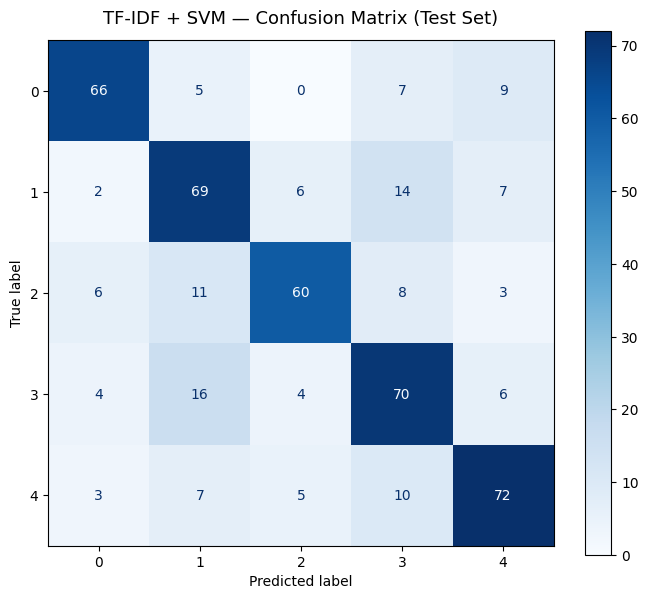

✓ Saved to svm_output/confusion_matrix.png


In [38]:
cm = confusion_matrix(y_test, y_test_pred, labels=classes)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=classes).plot(
    ax=ax, colorbar=True, cmap="Blues"
)
ax.set_title("TF-IDF + SVM — Confusion Matrix (Test Set)", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved to svm_output/confusion_matrix.png")


### A10 · Top features per class
One advantage of TF-IDF + SVM over BERT is **interpretability**. We can inspect which words/bigrams the model weighted most strongly for each class — giving human-readable insight into what drives predictions.



Class 0 — top 15 discriminating words/bigrams:
  stress                         +7.1881
  stressed                       +4.1730
  stress and                     +1.4965
  work                           +1.3238
  stressful                      +1.2499
  of stress                      +1.2013
  study                          +1.0827
  so stressed                    +1.0798
  burnout                        +1.0446
  stress sep                     +1.0375
  stressed about                 +0.9460
  college                        +0.9305
  stressing                      +0.9213
  relaxing                       +0.8933
  stressed and                   +0.8898

Class 1 — top 15 discriminating words/bigrams:
  depression                     +3.5479
  depressed                      +2.0726
  anymore                        +1.6572
  my depression                  +1.2463
  nothing                        +1.2316
  happy                          +1.2139
  myself                         +1.1946
  

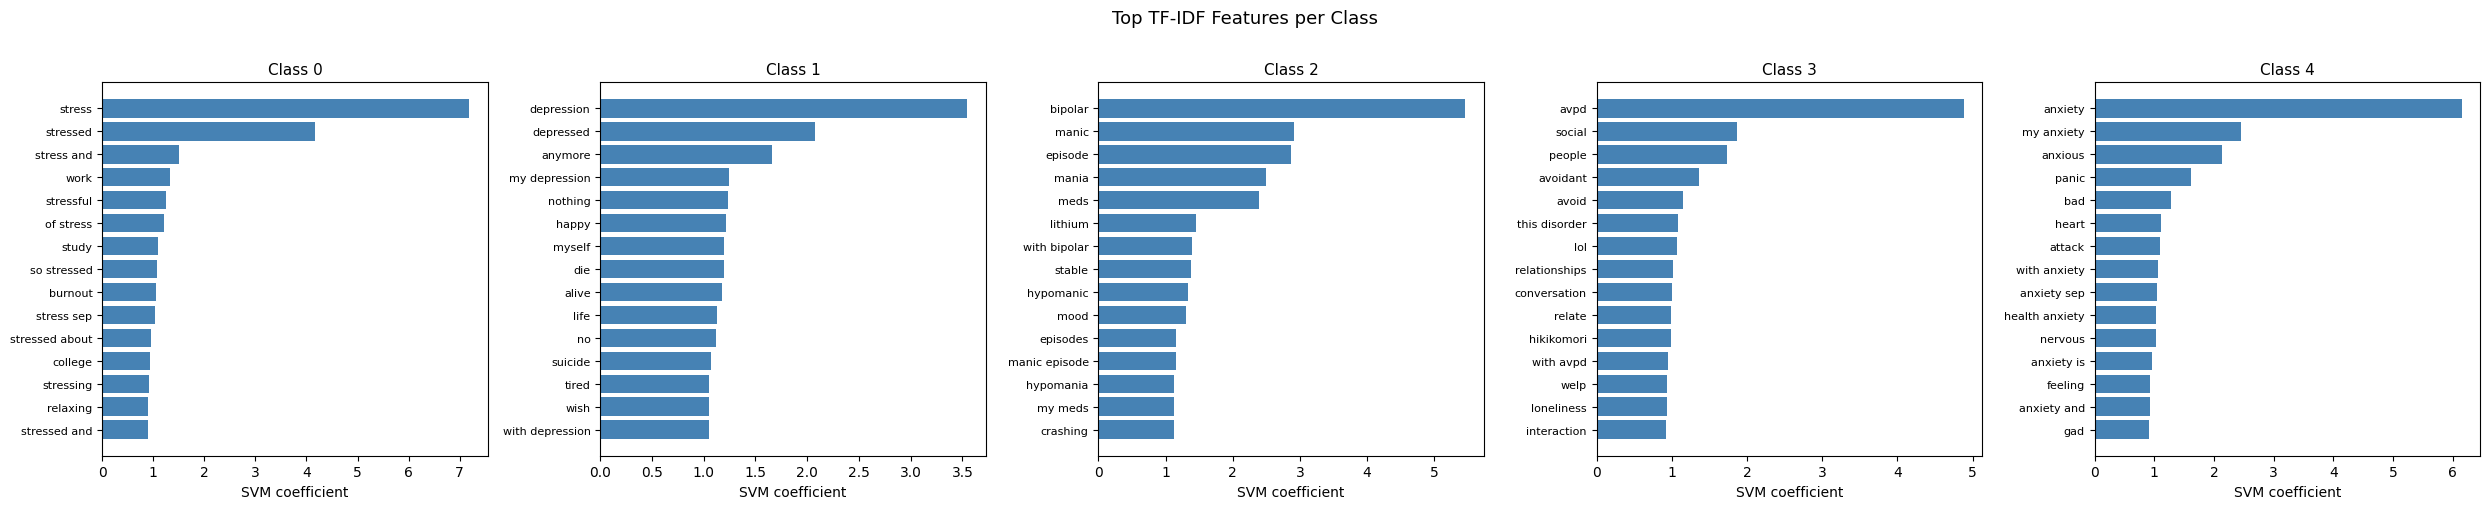

In [39]:
tfidf_vocab = best_pipeline.named_steps["tfidf"].get_feature_names_out()
inner_svc   = best_pipeline.named_steps["clf"].calibrated_classifiers_[0].estimator
coef_matrix = inner_svc.coef_    # shape: (n_classes, n_features)
TOP_N       = 15

fig, axes = plt.subplots(1, len(classes), figsize=(5 * len(classes), 5))
if len(classes) == 1:
    axes = [axes]

for i, cls in enumerate(inner_svc.classes_):
    top_idx    = np.argsort(coef_matrix[i])[-TOP_N:][::-1]
    top_words  = tfidf_vocab[top_idx]
    top_scores = coef_matrix[i][top_idx]

    print(f"\nClass {cls} — top {TOP_N} discriminating words/bigrams:")
    for w, s in zip(top_words, top_scores):
        print(f"  {w:<30} {s:+.4f}")

    axes[i].barh(range(TOP_N), top_scores[::-1], color="steelblue")
    axes[i].set_yticks(range(TOP_N))
    axes[i].set_yticklabels(top_words[::-1], fontsize=8)
    axes[i].set_title(f"Class {cls}", fontsize=11)
    axes[i].set_xlabel("SVM coefficient")

fig.suptitle("Top TF-IDF Features per Class", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top_features_per_class.png", dpi=150, bbox_inches="tight")
plt.show()


### A11 · Save the trained pipeline
We save the entire pipeline (TF-IDF + SVM) as a single `pickle` file. In Streamlit, you load it in one line and call `predict()` or `predict_proba()` directly on raw text — no preprocessing needed.


In [40]:
import pickle

model_path = OUTPUT_DIR / "tfidf_svm_pipeline.pkl"
with open(model_path, "wb") as f:
    pickle.dump(best_pipeline, f)

classes_path = OUTPUT_DIR / "classes.json"
with open(classes_path, "w") as f:
    json.dump({"classes": classes}, f)

summary = {
    "model"              : "TF-IDF + LinearSVC (calibrated)",
    "dataset_rows"       : len(df),
    "best_C"             : best_C,
    "best_cv_f1_weighted": round(best_cv, 4),
    "val_accuracy"       : round(val_acc, 4),
    "val_f1_weighted"    : round(val_f1, 4),
    "test_accuracy"      : round(test_acc, 4),
    "test_f1_weighted"   : round(test_f1, 4),
}
with open(OUTPUT_DIR / "svm_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("✓ Model saved!")
print(f"  Pipeline : {model_path}")
print(f"  Classes  : {classes_path}")
print(f"\nResults summary:")
print(json.dumps(summary, indent=2))

print("\n--- Streamlit quick-load snippet ---")
print("import pickle")
print(f"model = pickle.load(open('{model_path}', 'rb'))")
print("label = model.predict(['your text here'])[0]")
print("proba = model.predict_proba(['your text here'])[0]")


✓ Model saved!
  Pipeline : /content/svm_output/tfidf_svm_pipeline.pkl
  Classes  : /content/svm_output/classes.json

Results summary:
{
  "model": "TF-IDF + LinearSVC (calibrated)",
  "dataset_rows": 4697,
  "best_C": 1.0,
  "best_cv_f1_weighted": 0.7546,
  "val_accuracy": 0.7447,
  "val_f1_weighted": 0.7447,
  "test_accuracy": 0.717,
  "test_f1_weighted": 0.7187
}

--- Streamlit quick-load snippet ---
import pickle
model = pickle.load(open('/content/svm_output/tfidf_svm_pipeline.pkl', 'rb'))
label = model.predict(['your text here'])[0]
proba = model.predict_proba(['your text here'])[0]


---
## 8. Model Evaluation

### 📌 Code Explanation

After training, evaluation is performed on the **held-out test set** using the **best checkpoint** (highest validation F1 score), not the last epoch weights.

#### Metrics Explained
| Metric | Formula | Why it matters |
|--------|---------|----------------|
| **Accuracy** | Correct / Total | Overall correctness |
| **Weighted F1** | Harmonic mean of per-class precision & recall (weighted by class frequency) | Robust to class imbalance |
| **Precision** | TP / (TP + FP) | How many flagged posts truly belong to that class |
| **Recall (Sensitivity)** | TP / (TP + FN) | How many actual cases are caught — critical for mental health |
| **Confusion Matrix** | Actual vs Predicted grid | Reveals which classes are confused |

> **Sensitivity (Recall) is the most important metric** for mental health classification.  
> Missing a Depression or PTSD post (false negative) is more harmful than a false positive.


In [41]:
# ─── Load best checkpoint & test ─────────────────────────────────────────────
from transformers import BertForSequenceClassification

best_model = BertForSequenceClassification.from_pretrained(str(best_model_dir)).to(device)
ts_loss, ts_acc, ts_f1, ts_preds, ts_labels = evaluate(best_model, test_loader, device, "Test")

print(f"\n{'='*60}")
print("TEST RESULTS (best checkpoint)")
print(f"{'='*60}")
print(f"  Loss      : {ts_loss:.4f}")
print(f"  Accuracy  : {ts_acc:.4f}  ({ts_acc*100:.2f}%)")
print(f"  F1 (w)    : {ts_f1:.4f}")

label_names = [LABEL_MAP[i] for i in sorted(LABEL_MAP)]
print("\n  Classification Report:")
print(classification_report(ts_labels, ts_preds, target_names=label_names))


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


TEST RESULTS (best checkpoint)
  Loss      : 0.7383
  Accuracy  : 0.7447  (74.47%)
  F1 (w)    : 0.7465

  Classification Report:
              precision    recall  f1-score   support

      Normal       0.86      0.76      0.80        87
  Depression       0.72      0.72      0.72        98
     Anxiety       0.75      0.72      0.73        88
        PTSD       0.64      0.75      0.69       100
       Other       0.81      0.77      0.79        97

    accuracy                           0.74       470
   macro avg       0.75      0.74      0.75       470
weighted avg       0.75      0.74      0.75       470



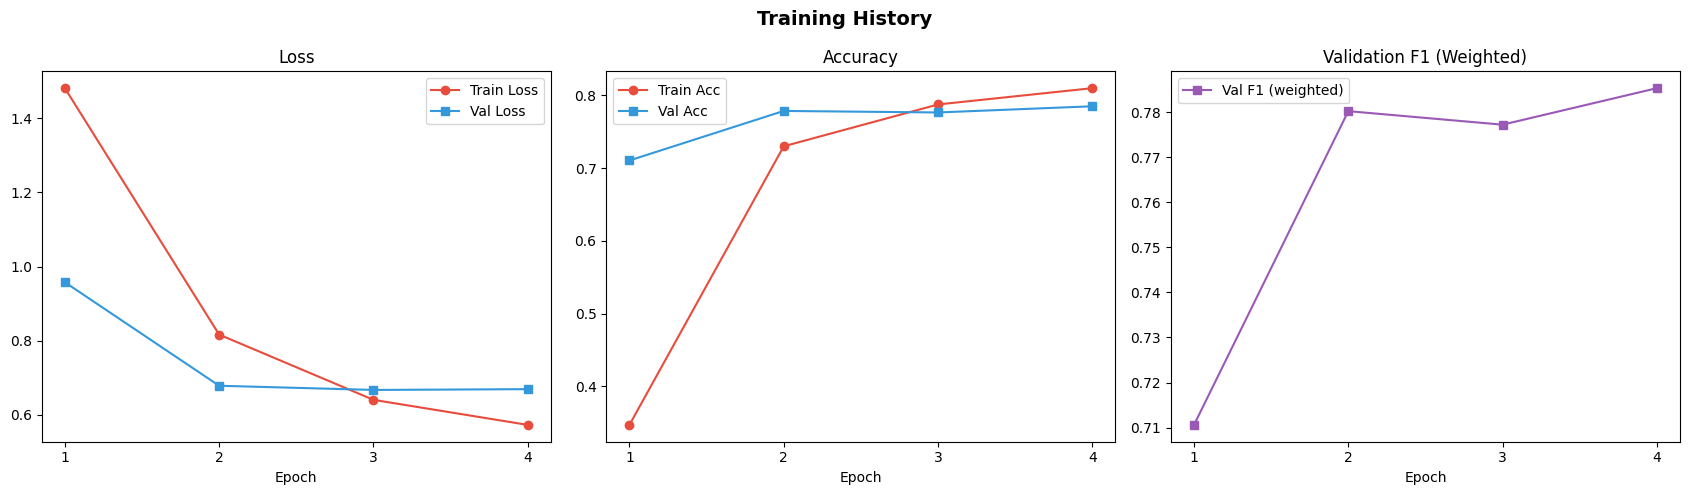

In [42]:
# ─── Training History Plots ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Training History", fontsize=14, fontweight='bold')
ep = range(1, EPOCHS + 1)

axes[0].plot(ep, history["train_loss"], 'o-', color='#e74c3c', label="Train Loss")
axes[0].plot(ep, history["val_loss"],   's-', color='#3498db', label="Val Loss")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

axes[1].plot(ep, history["train_acc"], 'o-', color='#e74c3c', label="Train Acc")
axes[1].plot(ep, history["val_acc"],   's-', color='#3498db', label="Val Acc")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

axes[2].plot(ep, history["val_f1"], 's-', color='#9b59b6', label="Val F1 (weighted)")
axes[2].set_title("Validation F1 (Weighted)"); axes[2].set_xlabel("Epoch"); axes[2].legend()
axes[2].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("training_history.png", dpi=150, bbox_inches='tight')
plt.show()


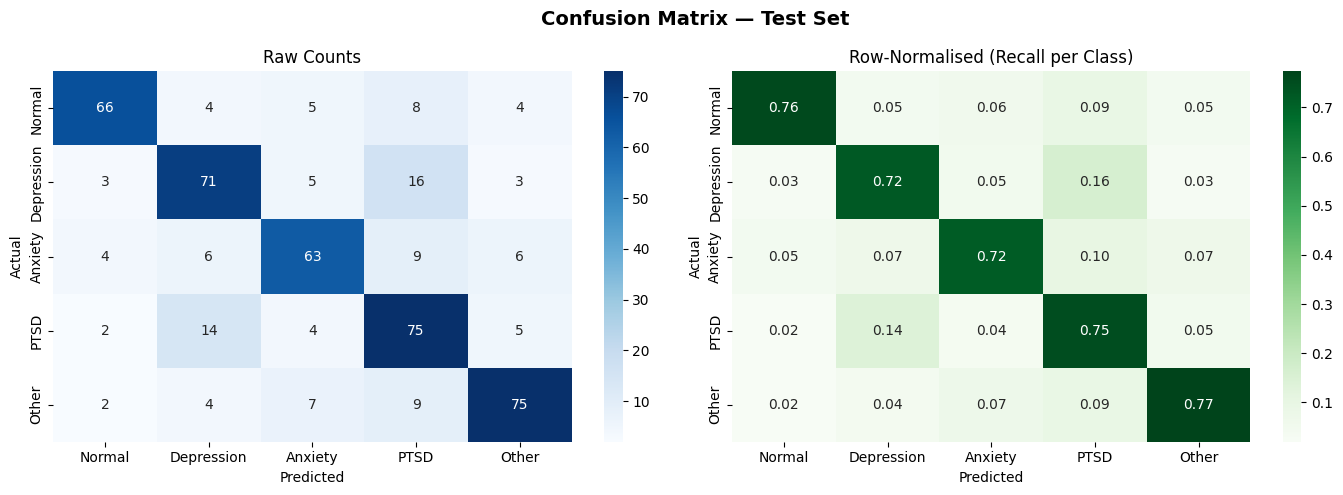

In [43]:
# ─── Confusion Matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(ts_labels, ts_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Confusion Matrix — Test Set", fontsize=14, fontweight='bold')

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names, ax=axes[0])
axes[0].set_title("Raw Counts")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

# Normalised (recall per class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=label_names, yticklabels=label_names, ax=axes[1])
axes[1].set_title("Row-Normalised (Recall per Class)")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()


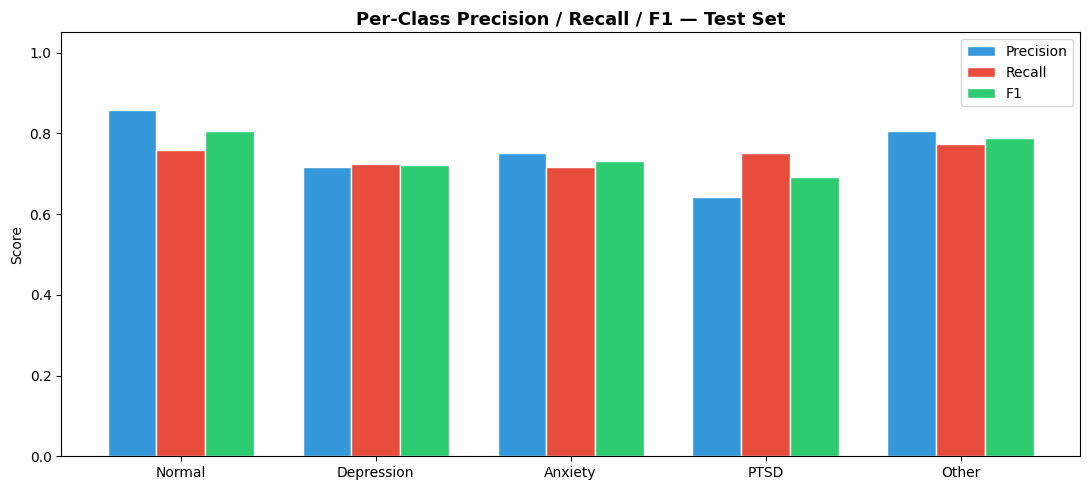

In [44]:
# ─── Per-class Precision / Recall / F1 bar chart ─────────────────────────────
from sklearn.metrics import precision_recall_fscore_support

prec, rec, f1_per, _ = precision_recall_fscore_support(
    ts_labels, ts_preds, average=None, labels=list(range(NUM_LABELS))
)

x   = np.arange(NUM_LABELS)
w   = 0.25
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w,   prec,    w, label="Precision", color='#3498db', edgecolor='white')
ax.bar(x,       rec,     w, label="Recall",    color='#e74c3c', edgecolor='white')
ax.bar(x + w,   f1_per,  w, label="F1",        color='#2ecc71', edgecolor='white')

ax.set_xticks(x); ax.set_xticklabels(label_names)
ax.set_ylim(0, 1.05)
ax.set_title("Per-Class Precision / Recall / F1 — Test Set", fontsize=13, fontweight='bold')
ax.set_ylabel("Score")
ax.legend()
plt.tight_layout()
plt.savefig("per_class_metrics.png", dpi=150, bbox_inches='tight')
plt.show()


In [45]:
# ─── Save test results ───────────────────────────────────────────────────────
results = {
    "test_loss":          round(ts_loss, 4),
    "test_accuracy":      round(ts_acc,  4),
    "test_f1_weighted":   round(ts_f1,   4),
    "best_val_f1":        round(best_val_f1, 4),
    "model_name":         MODEL_NAME,
    "max_len":            MAX_LEN,
    "batch_size":         BATCH_SIZE,
    "epochs":             EPOCHS,
    "learning_rate":      LR,
    "num_labels":         NUM_LABELS,
    "label_map":          LABEL_MAP,
}
with open(output_dir / "test_results.json", "w") as f:
    json.dump(results, f, indent=2)
print("✅ Test results saved → bert_output/test_results.json")
print(json.dumps(results, indent=2))


✅ Test results saved → bert_output/test_results.json
{
  "test_loss": 0.7383,
  "test_accuracy": 0.7447,
  "test_f1_weighted": 0.7465,
  "best_val_f1": 0.7853,
  "model_name": "bert-base-uncased",
  "max_len": 256,
  "batch_size": 16,
  "epochs": 4,
  "learning_rate": 2e-05,
  "num_labels": 5,
  "label_map": {
    "0": "Normal",
    "1": "Depression",
    "2": "Anxiety",
    "3": "PTSD",
    "4": "Other"
  }
}


---
## 9. Inference Helper

### 📌 Code Explanation

The `predict()` function loads a saved BERT checkpoint and runs batch inference on new texts.  
It returns both the **predicted class index** and **softmax probability scores** for all 5 classes.

This function is used directly by the Streamlit app — the app calls `predict()` on each submitted post and visualises the probabilities as a bar chart.

**Why return probabilities, not just the class?**  
Mental health classification should express *uncertainty*. A post might be 51% Depression / 34% Anxiety — showing the full distribution is more informative and responsible than a hard label.


In [46]:
def predict(
    texts:      list,
    model_dir:  str  = str(best_model_dir),
    max_len:    int  = MAX_LEN,
    batch_size: int  = 32,
) -> tuple:
    """
    Run inference on a list of raw text strings using a saved BERT checkpoint.

    Parameters
    ----------
    texts      : list[str]  — raw (or pre-cleaned) post texts
    model_dir  : str        — path to bert_output/best_model/
    max_len    : int        — must match the value used at training time
    batch_size : int        — inference batch size

    Returns
    -------
    preds : list[int]         — predicted class index per sample
    probs : list[list[float]] — softmax probability for each of the 5 classes
    """
    infer_device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    infer_tokenizer = BertTokenizer.from_pretrained(model_dir)
    infer_model     = BertForSequenceClassification.from_pretrained(model_dir).to(infer_device)
    infer_model.eval()

    all_preds, all_probs = [], []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i : i + batch_size]
        enc = infer_tokenizer(
            batch_texts,
            max_length           = max_len,
            padding              = "max_length",
            truncation           = True,
            return_attention_mask    = True,
            return_token_type_ids    = True,
            return_tensors           = "pt",
        )
        with torch.no_grad():
            outputs = infer_model(
                input_ids      = enc["input_ids"].to(infer_device),
                attention_mask = enc["attention_mask"].to(infer_device),
                token_type_ids = enc["token_type_ids"].to(infer_device),
            )
        probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()
        all_preds.extend(probs.argmax(axis=-1).tolist())
        all_probs.extend(probs.tolist())

    return all_preds, all_probs


# ── Quick demo ────────────────────────────────────────────────────────────────
demo_texts = [
    "I can't get out of bed anymore. Everything feels so heavy and pointless.",
    "Had a great day! Feeling really positive about the future.",
    "I keep having nightmares about what happened. I can't escape it.",
    "My heart races every time I think about tomorrow's presentation.",
]

preds, probs = predict(demo_texts)

print("\n🔍 Inference Results:\n")
for text, pred, prob in zip(demo_texts, preds, probs):
    print(f"  Input  : {text[:70]}...")
    print(f"  Label  : {LABEL_MAP[pred]} (confidence: {max(prob)*100:.1f}%)")
    print(f"  Scores : { {LABEL_MAP[i]: f'{p*100:.1f}%' for i, p in enumerate(prob)} }")
    print()


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


🔍 Inference Results:

  Input  : I can't get out of bed anymore. Everything feels so heavy and pointles...
  Label  : Depression (confidence: 56.2%)
  Scores : {'Normal': '13.3%', 'Depression': '56.2%', 'Anxiety': '8.3%', 'PTSD': '12.9%', 'Other': '9.4%'}

  Input  : Had a great day! Feeling really positive about the future....
  Label  : Depression (confidence: 43.4%)
  Scores : {'Normal': '29.3%', 'Depression': '43.4%', 'Anxiety': '4.7%', 'PTSD': '8.8%', 'Other': '13.9%'}

  Input  : I keep having nightmares about what happened. I can't escape it....
  Label  : Depression (confidence: 50.6%)
  Scores : {'Normal': '5.7%', 'Depression': '50.6%', 'Anxiety': '12.8%', 'PTSD': '19.0%', 'Other': '12.0%'}

  Input  : My heart races every time I think about tomorrow's presentation....
  Label  : Normal (confidence: 45.4%)
  Scores : {'Normal': '45.4%', 'Depression': '13.3%', 'Anxiety': '4.8%', 'PTSD': '14.9%', 'Other': '21.6%'}



---
## 10. Model Comparison — TF-IDF + SVM vs BERT

### 📌 Code Explanation

Compare both trained models side-by-side on the same held-out test set.  
Run this section **after** completing both the BERT training (Section 7) and TF-IDF+SVM training (Section 7b).

**What it shows:**
- A comparison table of Test Accuracy and weighted F1 for both models
- A grouped bar chart visualising the performance gap

**Expected outcome:** BERT outperforms TF-IDF+SVM because it captures contextual meaning (e.g. *"I can't feel anything"* means opposite things in different contexts), while TF-IDF treats every word as an independent bag-of-words feature.

| Metric | TF-IDF + SVM | BERT (fine-tuned) |
|--------|-------------|-------------------|
| Speed | Fast (seconds) | Slow (GPU needed) |
| Interpretability | High | Low |
| Accuracy | Good baseline | State-of-the-art |

Model Comparison:
                   Test Accuracy  Test F1 (w)
Model                                        
TF-IDF + SVM              0.7170       0.7187
BERT (fine-tuned)         0.7447       0.7465


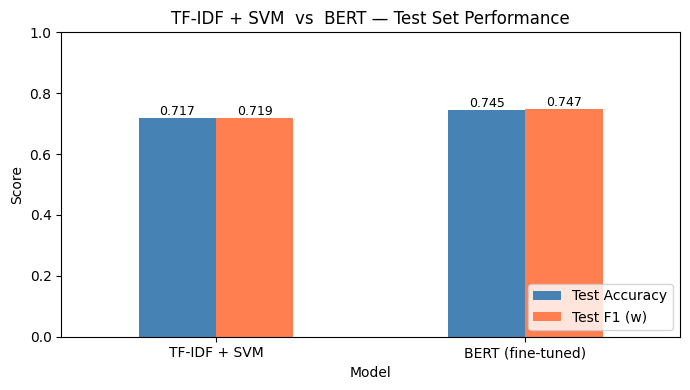


✓ Comparison chart saved.


In [48]:
from pathlib import Path
import json, pandas as pd
import matplotlib.pyplot as plt

# Load results
with open(Path("/content/svm_output") / "svm_summary.json") as f:
    svm_res = json.load(f)
with open(Path("/content/bert_output") / "test_results.json") as f:
    bert_res = json.load(f)

compare = pd.DataFrame({
    "Model"        : ["TF-IDF + SVM", "BERT (fine-tuned)"],
    "Test Accuracy": [svm_res["test_accuracy"],  bert_res["test_accuracy"]],
    "Test F1 (w)"  : [svm_res["test_f1_weighted"], bert_res["test_f1_weighted"]],
})
compare = compare.set_index("Model")
print("Model Comparison:")
print(compare.to_string())

# Bar chart
ax = compare.plot(kind="bar", figsize=(7, 4), rot=0, color=["steelblue", "coral"])
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.set_title("TF-IDF + SVM  vs  BERT — Test Set Performance")
ax.legend(loc="lower right")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}",
                (p.get_x() + p.get_width() / 2, p.get_height() + 0.01),
                ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("/content/model_comparison.png", dpi=150)
plt.show()
print("\n✓ Comparison chart saved.")


### ✅ Project Complete!

You now have a full end-to-end pipeline:

```
Raw Reddit CSV
    ↓ (Section 3-4)  EDA & exploration
    ↓ (Section 5)    Text cleaning & preprocessing
    ↓ (Section 6)    BERT tokenization → tensors
    ↓ (Section 7)    Fine-tune BertForSequenceClassification
    ↓ (Section 8)    Evaluate on test set (accuracy, F1, confusion matrix)
    ↓ (Section 9)    Inference helper function
    ↓ (Section 10)   Streamlit web app deployment
```

#### 📁 Output Files Generated
| File | Description |
|------|-------------|
| `bert_ready_dataset.csv` | Cleaned, preprocessed dataset |
| `bert_tensors.pt` | Full tokenized tensor pack |
| `bert_output/best_model/` | Best BERT checkpoint (by val F1) |
| `bert_output/training_history.json` | Epoch-by-epoch metrics |
| `bert_output/test_results.json` | Final test evaluation |
| `eda_*.png` | All EDA visualisation images |
| `training_history.png` | Loss/accuracy/F1 curves |
| `confusion_matrix.png` | Test set confusion matrix |

#### 🔑 Key Takeaways
- **BERT** outperforms TF-IDF+SVM for this task due to contextual understanding
- **Sensitivity (Recall)** is the most important metric for mental health classification
- **Balanced classes** (~1,200 per class) enable reliable training without oversampling
- **Responsible deployment** requires clear disclaimers — this is a research tool, not a diagnosis system
